---
## Step 0: Inventory local result files

This section scans `/Users/julianreynolds/Project/data/Results` and builds a per-file inventory: folder, file name, type, size, row count, number of columns, and the first five column names. Parquet files are inspected from metadata only, so the large prediction files are not loaded into memory. CSV files are counted by streaming line by line.


In [1]:
# ====================================================
# Inventory local model result files without loading big datasets
# ====================================================
from pathlib import Path
import csv
import json

import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display
from tqdm.auto import tqdm

RESULTS_DIR = Path("/Users/julianreynolds/Project/data/Results")
COLUMN_NAME_SEPARATOR = " | "
MAX_JSON_PARSE_BYTES = 100 * 1024 * 1024
GENERATED_INVENTORY_FILES = {"results_inventory.csv", "test_set_results_inventory.csv"}
# The stock-level OOS test set has exactly this many rows.
# I use it to keep only full test-set prediction files and exclude manifests,
# diagnostics, summaries, yearly split files, and other auxiliary outputs.
TEST_SET_ROW_COUNT = 2_136_916


def bytes_to_mb(n_bytes):
    return round(n_bytes / (1024 ** 2), 3)


def relative_folder(path):
    relative_parent = path.parent.relative_to(RESULTS_DIR)
    return "." if str(relative_parent) == "." else relative_parent.as_posix()


def column_text(columns):
    if not columns:
        return ""
    return COLUMN_NAME_SEPARATOR.join(str(column) for column in columns)


def first_columns_text(columns, n=5):
    if not columns:
        return ""
    return COLUMN_NAME_SEPARATOR.join(str(column) for column in columns[:n])


def detail_from_columns(columns, rows, row_groups=pd.NA, inspection_method="", notes=""):
    return {
        "rows": rows,
        "n_columns": len(columns),
        "first_5_columns": first_columns_text(columns),
        "columns": column_text(columns),
        "row_groups": row_groups,
        "inspection_method": inspection_method,
        "notes": notes,
    }


def inspect_parquet(path):
    parquet_file = pq.ParquetFile(path)
    metadata = parquet_file.metadata
    columns = list(parquet_file.schema_arrow.names)
    return detail_from_columns(
        columns=columns,
        rows=metadata.num_rows,
        row_groups=metadata.num_row_groups,
        inspection_method="parquet metadata only",
    )


def inspect_csv(path):
    last_error = None
    for encoding in ("utf-8-sig", "utf-8", "latin-1"):
        try:
            with path.open("r", encoding=encoding, newline="") as handle:
                sample = handle.read(65536)
                handle.seek(0)
                try:
                    dialect = csv.Sniffer().sniff(sample, delimiters=",;\t|")
                except csv.Error:
                    dialect = csv.excel
                reader = csv.reader(handle, dialect)
                header = next(reader, [])
                rows = sum(1 for _ in reader)

            return detail_from_columns(
                columns=header,
                rows=rows,
                inspection_method="csv header + streamed row count",
                notes=f"encoding={encoding}; delimiter={repr(dialect.delimiter)}",
            )
        except UnicodeDecodeError as error:
            last_error = error

    raise UnicodeDecodeError(
        "csv",
        b"",
        0,
        1,
        f"could not decode with utf-8-sig, utf-8, or latin-1: {last_error}",
    )


def inspect_json(path):
    if path.stat().st_size > MAX_JSON_PARSE_BYTES:
        return {
            "rows": pd.NA,
            "n_columns": pd.NA,
            "first_5_columns": "",
            "columns": "",
            "row_groups": pd.NA,
            "inspection_method": "json size only",
            "notes": f"skipped parse because file exceeds {bytes_to_mb(MAX_JSON_PARSE_BYTES)} MB",
        }

    with path.open("r", encoding="utf-8") as handle:
        data = json.load(handle)

    if isinstance(data, list):
        columns = sorted({key for row in data if isinstance(row, dict) for key in row.keys()})
        rows = len(data)
        note = "top-level JSON list"
    elif isinstance(data, dict):
        columns = list(data.keys())
        rows = 1
        note = "top-level JSON object"
    else:
        columns = []
        rows = 1
        note = f"top-level JSON {type(data).__name__}"

    return detail_from_columns(
        columns=columns,
        rows=rows,
        inspection_method="json parsed",
        notes=note,
    )


def inspect_result_file(path):
    stat = path.stat()
    suffix = path.suffix.lower().lstrip(".") or "unknown"
    base_record = {
        "folder": relative_folder(path),
        "file name": path.name,
        "relative_path": path.relative_to(RESULTS_DIR).as_posix(),
        "file_type": suffix,
        "size_mb": bytes_to_mb(stat.st_size),
        "modified_time": pd.Timestamp(stat.st_mtime, unit="s"),
    }

    try:
        if suffix == "parquet":
            detail = inspect_parquet(path)
        elif suffix == "csv":
            detail = inspect_csv(path)
        elif suffix == "json":
            detail = inspect_json(path)
        else:
            detail = {
                "rows": pd.NA,
                "n_columns": pd.NA,
                "first_5_columns": "",
                "columns": "",
                "row_groups": pd.NA,
                "inspection_method": "size only",
                "notes": "unsupported file type",
            }
    except Exception as error:
        detail = {
            "rows": pd.NA,
            "n_columns": pd.NA,
            "first_5_columns": "",
            "columns": "",
            "row_groups": pd.NA,
            "inspection_method": "failed",
            "notes": repr(error),
        }

    return {**base_record, **detail}


if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Results folder not found: {RESULTS_DIR}")

result_files = sorted(
    path
    for path in RESULTS_DIR.rglob("*")
    if path.is_file()
    and path.name not in GENERATED_INVENTORY_FILES
    and not path.name.startswith(".")
    and not path.name.startswith("._")
    and not path.name.endswith(".download")
)

records = [inspect_result_file(path) for path in tqdm(result_files, desc="Scanning result files")]
results_inventory = pd.DataFrame(records).sort_values(["folder", "file name"]).reset_index(drop=True)
# Keep only full stock-level test-set prediction files.
# These are the files with exactly 2,136,916 rows, matching the OOS test-set size.
# Smaller files are diagnostics/summaries/yearly chunks; larger combined files contain
# multiple model outputs stacked together, so they are not the individual datasets
# I want for the portfolio comparison input check.
test_set_inventory = (
    results_inventory
    .assign(rows_numeric=pd.to_numeric(results_inventory["rows"], errors="coerce"))
    .query("rows_numeric == @TEST_SET_ROW_COUNT")
    .drop(columns="rows_numeric")
    .reset_index(drop=True)
)
folder_inventory = (
    test_set_inventory
    .assign(rows_numeric=pd.to_numeric(test_set_inventory["rows"], errors="coerce"))
    .groupby("folder", dropna=False)
    .agg(
        total_size_mb=("size_mb", "sum"),
        test_set_rows=("rows_numeric", "sum"),
    )
    .reset_index()
)
folder_inventory["total_size_mb"] = folder_inventory["total_size_mb"].round(3)
folder_inventory["test_set_rows"] = folder_inventory["test_set_rows"].astype("Int64")

per_file_inventory = test_set_inventory[[
    "folder",
    "file name",
    "file_type",
    "size_mb",
    "rows",
    "n_columns",
    "first_5_columns",
    "inspection_method",
    "notes",
]]

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 180)

print(f"Scanned {len(results_inventory)} files from {RESULTS_DIR}")
print(f"Found {len(test_set_inventory)} files with {TEST_SET_ROW_COUNT:,} rows")
display(folder_inventory)
display(per_file_inventory)


/Users/julianreynolds/Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Scanning result files: 100%|██████████| 82/82 [00:01<00:00, 42.19it/s]

Scanned 82 files from /Users/julianreynolds/Project/data/Results
Found 13 files with 2,136,916 rows


,folder,total_size_mb,test_set_rows
0,fml_ols_enet_results,89.988,8547664
1,glm_3,46.749,2136916
2,nn_results,52.967,6410748
3,pcr_pls,298.322,4273832
4,tree_results,68.603,6410748


,folder,file name,file_type,size_mb,rows,n_columns,first_5_columns,inspection_method,notes
0,fml_ols_enet_results,FML_OLS_ENet_fixed_enet_h_recursive_oos_predictions.parquet,parquet,22.418,2136916,12,source_notebook | prediction_source | prediction_scope | model | test_year,parquet metadata only,
1,fml_ols_enet_results,FML_OLS_ENet_fixed_enet_recursive_oos_predictions.parquet,parquet,22.517,2136916,12,source_notebook | prediction_source | prediction_scope | model | test_year,parquet metadata only,
2,fml_ols_enet_results,FML_OLS_ENet_fixed_ols3_recursive_oos_predictions.parquet,parquet,22.526,2136916,9,source_notebook | prediction_source | prediction_scope | model | test_year,parquet metadata only,
3,fml_ols_enet_results,FML_OLS_ENet_fixed_ols_full_recursive_oos_predictions.parquet,parquet,22.527,2136916,9,source_notebook | prediction_source | prediction_scope | model | test_year,parquet metadata only,
4,glm_3,glm_3_stock_level_oos_predictions_with_ids.parquet,parquet,46.749,2136916,16,source_notebook | source_panel | prediction_source | prediction_scope | model,parquet metadata only,
5,nn_results,NN1_predictions.parquet,parquet,17.676,2136916,3,test_year | actual | predicted,parquet metadata only,
6,nn_results,NN3_predictions.parquet,parquet,17.673,2136916,3,test_year | actual | predicted,parquet metadata only,
7,nn_results,NN5_predictions.parquet,parquet,17.618,2136916,3,test_year | actual | predicted,parquet metadata only,
8,pcr_pls,pcr_predictions.csv,csv,152.151,2136916,8,permno | date | year | month | exchcd,csv header + streamed row count,"encoding=utf-8-sig; delimiter=','"
9,pcr_pls,pls_predictions.csv,csv,146.171,2136916,8,permno | date | year | month | exchcd,csv header + streamed row count,"encoding=utf-8-sig; delimiter=','"


---
## Step 0A: Inspect full columns for test-set files

This view keeps only the files with the full OOS test-set row count and displays each file name with its complete column list.


In [2]:
# ====================================================
# Show full column lists for the test-set files
# ====================================================
# This relies on the inventory cell above. It does not reload any large datasets;
# parquet columns come from metadata and CSV columns come from the header scan.
test_set_columns_view = (
    test_set_inventory[["file name", "columns"]]
    .sort_values("file name")
    .reset_index(drop=True)
)

display(test_set_columns_view)


,file name,columns
0,FML_OLS_ENet_fixed_enet_h_recursive_oos_predictions.parquet,source_notebook | prediction_source | prediction_scope | model | test_year | date | permno | prediction | predicted | alpha | l1_ratio | n_nonzero_features
1,FML_OLS_ENet_fixed_enet_recursive_oos_predictions.parquet,source_notebook | prediction_source | prediction_scope | model | test_year | date | permno | prediction | predicted | alpha | l1_ratio | n_nonzero_features
2,FML_OLS_ENet_fixed_ols3_recursive_oos_predictions.parquet,source_notebook | prediction_source | prediction_scope | model | test_year | date | permno | prediction | predicted
3,FML_OLS_ENet_fixed_ols_full_recursive_oos_predictions.parquet,source_notebook | prediction_source | prediction_scope | model | test_year | date | permno | prediction | predicted
4,GBRT_GKX_HUBER_predictions.parquet,test_year | date | permno | actual | predicted
5,NN1_predictions.parquet,test_year | actual | predicted
6,NN3_predictions.parquet,test_year | actual | predicted
7,NN5_predictions.parquet,test_year | actual | predicted
8,RF_predictions.parquet,test_year | date | permno | actual | predicted
9,TEST_recursive_predictions.parquet,permno | date | mvel1 | actual_return | rf_predicted | gbrt_predicted


---
## Step 1: Normalize all model predictions into one portfolio-ready stock panel

The portfolio code needs every model in the same bottom-up stock-level shape: one row per `(model, permno, date)` with a forecast, realized excess return, market equity, exchange code, sort characteristics, and lagged market equity for ex ante value weights.

The downloaded result files do not all contain the same information, so this section standardizes them carefully:

- **FML / OLS / ENet files** already have `permno`, `date`, and model forecasts, but they do not carry realized returns or the portfolio sort characteristics. I join them to `gkx2020_panel_trimmed.parquet` by `permno,date` to recover `ret_excess`, `me`, `exchcd`, `bm`, `agr`, `operprof`, and `mom12m`.
- **GLM** already has stock identifiers plus `ret_excess`, `me`, `exchcd`, and forecasts, but it is still missing the sort characteristics used for HML/CMA/RMW/UMD. I use the same panel join so every model uses one canonical source for portfolio characteristics.
- **PCR and PLS** store their forecast as `pred` and include identifiers, returns, exchange code, and market equity. I rename `pred` to `prediction` and join the panel for the missing sort characteristics.
- **RF and GBRT** store `permno`, `date`, `actual`, and `predicted`. I rename `predicted` to `prediction` and join the panel for market equity, exchange code, realized return, and characteristics.
- **NN1/NN3/NN5** only store `test_year`, `actual`, and `predicted`. Because they were saved in the same annual OOS test-row order used during training, I reconstruct `permno`, `date`, and all portfolio identity columns from the GKX panel using the original 1987-2021 annual test ordering, then attach the NN forecasts row by row.
- **`TEST_recursive_predictions.parquet`** is not loaded by default because it duplicates RF and GBRT in one combined tree file; using it together with `RF_predictions.parquet` and `GBRT_predictions.parquet` would double count those models.

Finally, I compute `weight_me` from `Monthly_returns_crsp.csv` as prior-month market equity. That is needed because portfolios must be weighted using information known before the forecast-month return is realized.


In [3]:
# ====================================================
# Normalize all model prediction files for portfolio analysis
# ====================================================
from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
from IPython.display import display

# Keep this notebook self-contained. If a previous cell defined SMOKE_TEST, respect it;
# otherwise default to the full 1987-2021 OOS period used by the downloaded files.
SMOKE_TEST = globals().get("SMOKE_TEST", False)
PORTFOLIO_FORECAST_MODE = "smoke" if SMOKE_TEST else "full"
PORTFOLIO_MARKET_TOP_N = 500
SAVE_PORTFOLIO_MEMBERSHIP = PORTFOLIO_FORECAST_MODE == "smoke"
SMB_INCLUDE_MOMENTUM_SORT = False
SAVE_NORMALIZED_STOCK_PREDICTIONS = False

PROJECT_ROOT = Path("/Users/julianreynolds/Project")
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = DATA_DIR / "Results"
PANEL_PATH = DATA_DIR / "gkx2020_panel_trimmed.parquet"
CRSP_MONTHLY_PATH = DATA_DIR / "Monthly_returns_crsp.csv"
output_dir = PROJECT_ROOT / "output" / "portfolio_analysis"
output_dir.mkdir(parents=True, exist_ok=True)

TEST_YEARS = list(range(1987, 2022))
TEST_SET_ROW_COUNT = 2_136_916
PORTFOLIO_SORT_CHARACTERISTICS = ["bm", "agr", "operprof", "mom12m"]
PANEL_REFERENCE_COLUMNS = [
    "permno",
    "date",
    "ret_excess",
    "me",
    "exchcd",
    *PORTFOLIO_SORT_CHARACTERISTICS,
]
PORTFOLIO_REQUIRED_COLUMNS = [
    "model",
    "permno",
    "date",
    "prediction",
    "ret_excess",
    "me",
    "exchcd",
    "weight_me",
    *PORTFOLIO_SORT_CHARACTERISTICS,
]

# Each entry says how to turn one downloaded result file into the common schema.
# keyed = file already has permno/date, so I can join the GKX panel by those keys.
# row_order = file lacks permno/date, so I attach the GKX panel's annual OOS rows by order.
PREDICTION_FILE_SPECS = [
    {
        "model": "OLS-3",
        "folder": "fml_ols_enet_results",
        "file_name": "FML_OLS_ENet_fixed_ols3_recursive_oos_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "prediction",
        "actual_col": None,
        "why": "FML OLS-3 has stock keys and forecasts only; panel join supplies realized returns and portfolio characteristics.",
    },
    {
        "model": "OLS-Full",
        "folder": "fml_ols_enet_results",
        "file_name": "FML_OLS_ENet_fixed_ols_full_recursive_oos_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "prediction",
        "actual_col": None,
        "why": "FML full OLS has stock keys and forecasts only; panel join supplies realized returns and portfolio characteristics.",
    },
    {
        "model": "ENet",
        "folder": "fml_ols_enet_results",
        "file_name": "FML_OLS_ENet_fixed_enet_recursive_oos_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "prediction",
        "actual_col": None,
        "why": "Elastic Net has stock keys and forecasts; alpha/l1 metadata is retained only in the source file, while portfolio inputs come from the panel join.",
    },
    {
        "model": "ENet-H",
        "folder": "fml_ols_enet_results",
        "file_name": "FML_OLS_ENet_fixed_enet_h_recursive_oos_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "prediction",
        "actual_col": None,
        "why": "Huber Elastic Net has stock keys and forecasts; panel join adds realized returns, exchange code, market equity, and sort characteristics.",
    },
    {
        "model": "GLM",
        "folder": "glm_3",
        "file_name": "glm_3_stock_level_oos_predictions_with_ids.parquet",
        "loader": "keyed",
        "prediction_col": "prediction",
        "actual_col": "actual",
        "why": "GLM already has identifiers, actuals, returns, exchange code, and market equity; panel join adds the missing sort characteristics and keeps definitions consistent.",
    },
    {
        "model": "PCR",
        "folder": "pcr_pls",
        "file_name": "pcr_predictions.csv",
        "loader": "keyed",
        "prediction_col": "pred",
        "actual_col": "ret_excess",
        "why": "PCR stores forecasts as pred and already has stock keys; rename pred to prediction and join panel for sort characteristics.",
    },
    {
        "model": "PLS",
        "folder": "pcr_pls",
        "file_name": "pls_predictions.csv",
        "loader": "keyed",
        "prediction_col": "pred",
        "actual_col": "ret_excess",
        "why": "PLS stores forecasts as pred and already has stock keys; rename pred to prediction and join panel for sort characteristics.",
    },
    {
        "model": "RF",
        "folder": "tree_results",
        "file_name": "RF_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "predicted",
        "actual_col": "actual",
        "why": "RF stores only identifiers, actual, and predicted; panel join adds returns, market equity, exchange code, and sort characteristics.",
    },
    {
        "model": "GBRT",
        "folder": "tree_results",
        "file_name": "GBRT_GKX_HUBER_predictions.parquet",
        "loader": "keyed",
        "prediction_col": "predicted",
        "actual_col": "actual",
        "why": "GBRT stores only identifiers, actual, and predicted; panel join adds returns, market equity, exchange code, and sort characteristics.",
    },
    {
        "model": "NN1",
        "folder": "nn_results",
        "file_name": "NN1_predictions.parquet",
        "loader": "row_order",
        "prediction_col": "predicted",
        "actual_col": "actual",
        "why": "NN1 lacks permno/date, so we reconstruct stock identity from the panel using the same annual OOS row order used by training.",
    },
    {
        "model": "NN3",
        "folder": "nn_results",
        "file_name": "NN3_predictions.parquet",
        "loader": "row_order",
        "prediction_col": "predicted",
        "actual_col": "actual",
        "why": "NN3 lacks permno/date, so we reconstruct stock identity from the panel using the same annual OOS row order used by training.",
    },
    {
        "model": "NN5",
        "folder": "nn_results",
        "file_name": "NN5_predictions.parquet",
        "loader": "row_order",
        "prediction_col": "predicted",
        "actual_col": "actual",
        "why": "NN5 lacks permno/date, so we reconstruct stock identity from the panel using the same annual OOS row order used by training.",
    },
]

EXCLUDED_FULL_TEST_SET_FILES = pd.DataFrame([
    {
        "folder": "tree_results",
        "file name": "TEST_recursive_predictions.parquet",
        "reason": "Contains RF and GBRT together. Excluded to avoid double counting because RF_predictions.parquet and GBRT_GKX_HUBER_predictions.parquet are loaded separately.",
    }
])


def normalize_prediction_date(series: pd.Series) -> pd.Series:
    """Normalize all dates to month-start timestamps so files and panel join cleanly."""
    return pd.to_datetime(series).dt.to_period("M").dt.to_timestamp()


def read_prediction_file(path: Path) -> pd.DataFrame:
    """Read parquet or CSV prediction files using the extension only."""
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported prediction file type: {path}")


def compact_list(values) -> str:
    return ", ".join(str(value) for value in values)


def missing_from_input(input_columns, needed_columns) -> str:
    missing = [column for column in needed_columns if column not in input_columns]
    return compact_list(missing) if missing else "none"


def build_oos_panel_reference(panel_path: Path) -> pd.DataFrame:
    """Load only the columns needed to enrich predictions and reconstruct NN rows."""
    if not panel_path.exists():
        raise FileNotFoundError(f"Missing GKX panel: {panel_path}")

    panel = pd.read_parquet(panel_path, columns=PANEL_REFERENCE_COLUMNS)
    panel["date"] = normalize_prediction_date(panel["date"])
    panel["test_year"] = panel["date"].dt.year.astype("int16")

    annual_frames = []
    for year in TEST_YEARS:
        annual = panel.loc[panel["test_year"] == year].copy()
        if annual.empty:
            raise ValueError(f"No panel rows found for test year {year}.")
        annual_frames.append(annual)

    oos_panel = pd.concat(annual_frames, ignore_index=True)
    if len(oos_panel) != TEST_SET_ROW_COUNT:
        raise ValueError(
            f"Expected {TEST_SET_ROW_COUNT:,} OOS panel rows, found {len(oos_panel):,}. "
            "The row-order NN reconstruction would be unsafe."
        )

    duplicate_keys = oos_panel.duplicated(["permno", "date"]).sum()
    if duplicate_keys:
        raise ValueError(f"Panel has {duplicate_keys:,} duplicate permno/date rows in the OOS period.")

    for column in ["ret_excess", "me", *PORTFOLIO_SORT_CHARACTERISTICS]:
        oos_panel[column] = pd.to_numeric(oos_panel[column], errors="coerce").astype("float32")
    oos_panel["permno"] = pd.to_numeric(oos_panel["permno"], errors="raise").astype("int64")
    oos_panel["exchcd"] = pd.to_numeric(oos_panel["exchcd"], errors="coerce").astype("float32")
    return oos_panel


def attach_panel_by_key(pred_df: pd.DataFrame, spec: dict, panel_reference: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Normalize a file that already has permno/date keys, then enrich from the panel."""
    path = RESULTS_DIR / spec["folder"] / spec["file_name"]
    input_columns = list(pred_df.columns)
    required_input = ["permno", "date", spec["prediction_col"]]
    if spec["actual_col"] is not None:
        required_input.append(spec["actual_col"])
    missing_input = [column for column in required_input if column not in pred_df.columns]
    if missing_input:
        raise ValueError(f"{path.name} is missing required input columns: {missing_input}")

    working = pd.DataFrame({
        "permno": pd.to_numeric(pred_df["permno"], errors="raise").astype("int64"),
        "date": normalize_prediction_date(pred_df["date"]),
        "prediction": pd.to_numeric(pred_df[spec["prediction_col"]], errors="coerce").astype("float32"),
    })
    if spec["actual_col"] is not None:
        working["actual"] = pd.to_numeric(pred_df[spec["actual_col"]], errors="coerce").astype("float32")

    merged = working.merge(
        panel_reference,
        on=["permno", "date"],
        how="left",
        validate="many_to_one",
        indicator=True,
    )
    missing_panel_rows = int((merged["_merge"] != "both").sum())
    merged = merged.drop(columns="_merge")

    if "actual" not in merged.columns:
        merged["actual"] = merged["ret_excess"]
        actual_source = "panel ret_excess"
        max_actual_gap = 0.0
    else:
        actual_source = spec["actual_col"]
        actual_gap = (merged["actual"].astype("float64") - merged["ret_excess"].astype("float64")).abs()
        max_actual_gap = float(actual_gap.max(skipna=True))

    merged.insert(0, "model", spec["model"])
    merged["source_folder"] = spec["folder"]
    merged["source_file"] = spec["file_name"]

    audit = {
        "model": spec["model"],
        "source_file": spec["file_name"],
        "loader": "permno/date panel join",
        "input_rows": len(pred_df),
        "output_rows": len(merged),
        "prediction_column_used": spec["prediction_col"],
        "actual_source": actual_source,
        "missing_input_before_enrichment": missing_from_input(
            input_columns,
            ["permno", "date", "prediction", "ret_excess", "me", "exchcd", *PORTFOLIO_SORT_CHARACTERISTICS, "weight_me"],
        ),
        "missing_panel_rows": missing_panel_rows,
        "max_actual_vs_panel_ret_excess_gap": max_actual_gap,
        "normalization_note": spec["why"],
    }
    return merged, audit


def attach_panel_by_row_order(pred_df: pd.DataFrame, spec: dict, oos_identity: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Normalize an NN file by attaching the canonical OOS panel rows by saved row order."""
    input_columns = list(pred_df.columns)
    path = RESULTS_DIR / spec["folder"] / spec["file_name"]
    required_input = ["test_year", spec["prediction_col"], spec["actual_col"]]
    missing_input = [column for column in required_input if column not in pred_df.columns]
    if missing_input:
        raise ValueError(f"{path.name} is missing required input columns: {missing_input}")
    if len(pred_df) != len(oos_identity):
        raise ValueError(
            f"{path.name}: prediction rows ({len(pred_df):,}) do not match "
            f"OOS identity rows ({len(oos_identity):,})."
        )

    frame = oos_identity.copy()
    nn_test_year = pd.to_numeric(pred_df["test_year"], errors="raise").astype("int16")
    test_year_mismatches = int((nn_test_year.to_numpy() != frame["test_year"].to_numpy()).sum())
    if test_year_mismatches:
        raise ValueError(
            f"{path.name}: {test_year_mismatches:,} test_year rows do not match the panel OOS ordering."
        )

    frame.insert(0, "model", spec["model"])
    frame["prediction"] = pd.to_numeric(pred_df[spec["prediction_col"]], errors="coerce").astype("float32")
    frame["actual"] = pd.to_numeric(pred_df[spec["actual_col"]], errors="coerce").astype("float32")
    frame["source_folder"] = spec["folder"]
    frame["source_file"] = spec["file_name"]

    actual_gap = (frame["actual"].astype("float64") - frame["ret_excess"].astype("float64")).abs()
    audit = {
        "model": spec["model"],
        "source_file": spec["file_name"],
        "loader": "annual OOS row-order reconstruction",
        "input_rows": len(pred_df),
        "output_rows": len(frame),
        "prediction_column_used": spec["prediction_col"],
        "actual_source": spec["actual_col"],
        "missing_input_before_enrichment": missing_from_input(
            input_columns,
            ["permno", "date", "prediction", "ret_excess", "me", "exchcd", *PORTFOLIO_SORT_CHARACTERISTICS, "weight_me"],
        ),
        "missing_panel_rows": 0,
        "max_actual_vs_panel_ret_excess_gap": float(actual_gap.max(skipna=True)),
        "normalization_note": spec["why"],
    }
    return frame, audit


def add_ex_ante_market_equity(stock_predictions: pd.DataFrame, crsp_path: Path) -> pd.DataFrame:
    """Attach prior-month market equity for ex ante portfolio weights."""
    if not crsp_path.exists():
        raise FileNotFoundError(f"Missing CRSP monthly file: {crsp_path}")

    crsp_me = pd.read_csv(crsp_path, usecols=["permno", "date", "me"])
    crsp_me["permno"] = pd.to_numeric(crsp_me["permno"], errors="raise").astype("int64")
    crsp_me["forecast_month"] = pd.to_datetime(crsp_me["date"]).dt.to_period("M")
    crsp_me["me"] = pd.to_numeric(crsp_me["me"], errors="coerce").astype("float32")
    crsp_me = crsp_me.sort_values(["permno", "forecast_month"])
    crsp_me["weight_me"] = crsp_me.groupby("permno", sort=False)["me"].shift(1).astype("float32")
    crsp_me = crsp_me[["permno", "forecast_month", "weight_me"]]

    out = stock_predictions.copy()
    out["forecast_month"] = pd.to_datetime(out["date"]).dt.to_period("M")
    out = out.merge(
        crsp_me,
        on=["permno", "forecast_month"],
        how="left",
        validate="many_to_one",
    )
    out = out.drop(columns="forecast_month")
    return out


def finalize_stock_prediction_dtypes(stock_predictions: pd.DataFrame) -> pd.DataFrame:
    """Reduce memory and enforce numeric columns before portfolio construction."""
    out = stock_predictions.copy()
    out["model"] = out["model"].astype("category")
    out["source_folder"] = out["source_folder"].astype("category")
    out["source_file"] = out["source_file"].astype("category")
    out["permno"] = pd.to_numeric(out["permno"], errors="raise").astype("int64")
    out["date"] = normalize_prediction_date(out["date"])
    out["test_year"] = pd.to_numeric(out["test_year"], errors="coerce").astype("int16")
    out["exchcd"] = pd.to_numeric(out["exchcd"], errors="coerce").astype("float32")
    for column in ["prediction", "actual", "ret_excess", "me", "weight_me", *PORTFOLIO_SORT_CHARACTERISTICS]:
        out[column] = pd.to_numeric(out[column], errors="coerce").astype("float32")
    return out.sort_values(["model", "date", "permno"]).reset_index(drop=True)


def build_all_model_stock_predictions() -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load, standardize, enrich, and audit every portfolio-relevant model file."""
    oos_panel_reference = build_oos_panel_reference(PANEL_PATH)

    frames = []
    audit_rows = []
    for spec in PREDICTION_FILE_SPECS:
        path = RESULTS_DIR / spec["folder"] / spec["file_name"]
        if not path.exists():
            raise FileNotFoundError(f"Missing prediction file for {spec['model']}: {path}")

        pred_df = read_prediction_file(path)
        if len(pred_df) != TEST_SET_ROW_COUNT:
            raise ValueError(
                f"{path.name}: expected {TEST_SET_ROW_COUNT:,} rows, found {len(pred_df):,}."
            )

        if spec["loader"] == "keyed":
            frame, audit = attach_panel_by_key(pred_df, spec, oos_panel_reference)
        elif spec["loader"] == "row_order":
            frame, audit = attach_panel_by_row_order(pred_df, spec, oos_panel_reference)
        else:
            raise ValueError(f"Unknown loader for {spec['model']}: {spec['loader']}")

        frames.append(frame)
        audit_rows.append(audit)
        del pred_df, frame
        gc.collect()

    stock_predictions = pd.concat(frames, ignore_index=True, copy=False)
    del frames
    gc.collect()

    stock_predictions = add_ex_ante_market_equity(stock_predictions, CRSP_MONTHLY_PATH)
    stock_predictions = finalize_stock_prediction_dtypes(stock_predictions)

    audit = pd.DataFrame(audit_rows)
    post_checks = (
        stock_predictions
        .groupby("model", observed=True)
        .agg(
            final_rows=("prediction", "size"),
            unique_permno=("permno", "nunique"),
            start_date=("date", "min"),
            end_date=("date", "max"),
            missing_prediction_share=("prediction", lambda s: float(s.isna().mean() * 100)),
            missing_ret_excess_share=("ret_excess", lambda s: float(s.isna().mean() * 100)),
            missing_weight_me_share=("weight_me", lambda s: float(s.isna().mean() * 100)),
            missing_sort_char_share=("bm", lambda s: float(stock_predictions.loc[s.index, PORTFOLIO_SORT_CHARACTERISTICS].isna().any(axis=1).mean() * 100)),
        )
        .reset_index()
    )
    audit = audit.merge(post_checks, on="model", how="left")
    audit["ready_for_portfolio_code"] = (
        audit["final_rows"].eq(TEST_SET_ROW_COUNT)
        & audit["missing_panel_rows"].eq(0)
        & audit["missing_prediction_share"].eq(0)
        & audit["missing_ret_excess_share"].eq(0)
    )
    return stock_predictions, audit


stock_predictions, prediction_normalization_audit = build_all_model_stock_predictions()

if SAVE_NORMALIZED_STOCK_PREDICTIONS:
    normalized_path = output_dir / "all_model_stock_predictions_with_ids.parquet"
    stock_predictions.to_parquet(normalized_path, index=False)
    print(f"Saved normalized stock prediction panel: {normalized_path}")
else:
    print("Normalized stock prediction panel kept in memory; set SAVE_NORMALIZED_STOCK_PREDICTIONS=True to write it.")

print(f"Normalized stock prediction panel shape: {stock_predictions.shape}")
print(f"Models loaded: {stock_predictions['model'].nunique()}")
print(f"Output directory for portfolio results: {output_dir}")

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 160)

print("\nNormalization audit by source file:")
display(prediction_normalization_audit[[
    "model",
    "source_file",
    "loader",
    "input_rows",
    "output_rows",
    "prediction_column_used",
    "actual_source",
    "missing_input_before_enrichment",
    "missing_panel_rows",
    "max_actual_vs_panel_ret_excess_gap",
    "missing_weight_me_share",
    "ready_for_portfolio_code",
    "normalization_note",
]])

print("\nFull-row test-set files intentionally excluded:")
display(EXCLUDED_FULL_TEST_SET_FILES)

print("\nPortfolio-ready preview:")
display(stock_predictions[[
    "model",
    "permno",
    "date",
    "ret_excess",
    "prediction",
    "actual",
    "me",
    "weight_me",
    "exchcd",
    "bm",
    "agr",
    "operprof",
    "mom12m",
]].head(12))


Normalized stock prediction panel kept in memory; set SAVE_NORMALIZED_STOCK_PREDICTIONS=True to write it.
Normalized stock prediction panel shape: (25642992, 16)
Models loaded: 12
Output directory for portfolio results: /Users/julianreynolds/Project/output/portfolio_analysis

Normalization audit by source file:


,model,source_file,loader,input_rows,output_rows,prediction_column_used,actual_source,missing_input_before_enrichment,missing_panel_rows,max_actual_vs_panel_ret_excess_gap,missing_weight_me_share,ready_for_portfolio_code,normalization_note
0,OLS-3,FML_OLS_ENet_fixed_ols3_recursive_oos_predictions.parquet,permno/date panel join,2136916,2136916,prediction,panel ret_excess,"ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,FML OLS-3 has stock keys and forecasts only; panel join supplies realized returns and portfolio characteristics.
1,OLS-Full,FML_OLS_ENet_fixed_ols_full_recursive_oos_predictions.parquet,permno/date panel join,2136916,2136916,prediction,panel ret_excess,"ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,FML full OLS has stock keys and forecasts only; panel join supplies realized returns and portfolio characteristics.
2,ENet,FML_OLS_ENet_fixed_enet_recursive_oos_predictions.parquet,permno/date panel join,2136916,2136916,prediction,panel ret_excess,"ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"Elastic Net has stock keys and forecasts; alpha/l1 metadata is retained only in the source file, while portfolio inputs come from the panel join."
3,ENet-H,FML_OLS_ENet_fixed_enet_h_recursive_oos_predictions.parquet,permno/date panel join,2136916,2136916,prediction,panel ret_excess,"ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"Huber Elastic Net has stock keys and forecasts; panel join adds realized returns, exchange code, market equity, and sort characteristics."
4,GLM,glm_3_stock_level_oos_predictions_with_ids.parquet,permno/date panel join,2136916,2136916,prediction,actual,"bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"GLM already has identifiers, actuals, returns, exchange code, and market equity; panel join adds the missing sort characteristics and keeps definitions cons..."
5,PCR,pcr_predictions.csv,permno/date panel join,2136916,2136916,pred,ret_excess,"prediction, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,PCR stores forecasts as pred and already has stock keys; rename pred to prediction and join panel for sort characteristics.
6,PLS,pls_predictions.csv,permno/date panel join,2136916,2136916,pred,ret_excess,"prediction, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,PLS stores forecasts as pred and already has stock keys; rename pred to prediction and join panel for sort characteristics.
7,RF,RF_predictions.parquet,permno/date panel join,2136916,2136916,predicted,actual,"prediction, ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"RF stores only identifiers, actual, and predicted; panel join adds returns, market equity, exchange code, and sort characteristics."
8,GBRT,GBRT_GKX_HUBER_predictions.parquet,permno/date panel join,2136916,2136916,predicted,actual,"prediction, ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"GBRT stores only identifiers, actual, and predicted; panel join adds returns, market equity, exchange code, and sort characteristics."
9,NN1,NN1_predictions.parquet,annual OOS row-order reconstruction,2136916,2136916,predicted,actual,"permno, date, prediction, ret_excess, me, exchcd, bm, agr, operprof, mom12m, weight_me",0,0.0,0.016753,True,"NN1 lacks permno/date, so we reconstruct stock identity from the panel using the same annual OOS row order used by training."



Full-row test-set files intentionally excluded:


,folder,file name,reason
0,tree_results,TEST_recursive_predictions.parquet,Contains RF and GBRT together. Excluded to avoid double counting because RF_predictions.parquet and GBRT_GKX_HUBER_predictions.parquet are loaded separately.



Portfolio-ready preview:


,model,permno,date,ret_excess,prediction,actual,me,weight_me,exchcd,bm,agr,operprof,mom12m
0,ENet,10000,1987-01-01,-0.216272,0.006066,-0.216272,1.581531,1.981566,3.0,0.0,0.0,0.0,0.000000
1,ENet,10001,1987-01-01,-0.039865,-0.007671,-0.039865,6.689250,6.937000,3.0,0.0,0.0,0.0,0.093460
2,ENet,10002,1987-01-01,0.091809,0.000935,0.091809,15.935938,14.540625,3.0,0.0,0.0,0.0,0.192254
3,ENet,10003,1987-01-01,0.125719,-0.002972,0.125719,47.523750,42.061249,3.0,0.0,0.0,0.0,-0.227030
4,ENet,10005,1987-01-01,0.662516,-0.010486,0.662516,0.722812,0.433688,3.0,0.0,0.0,0.0,-0.973918
5,ENet,10007,1987-01-01,0.317278,-0.000694,0.317278,30.941250,23.415001,3.0,0.0,0.0,0.0,-0.894882
6,ENet,10008,1987-01-01,-0.004151,-0.012858,-0.004151,44.174999,44.174999,3.0,0.0,0.0,0.0,-0.492195
7,ENet,10009,1987-01-01,0.031849,-0.010841,0.031849,11.548875,11.212500,3.0,0.0,0.0,0.0,-0.168939
8,ENet,10010,1987-01-01,0.020849,-0.016127,0.020849,8.569000,8.360000,3.0,0.0,0.0,0.0,-0.930449
9,ENet,10012,1987-01-01,-0.524151,0.001256,-0.524151,2.637750,5.495313,3.0,0.0,0.0,0.0,-0.735230


---
## Step 2: Define Bottom-Up Portfolio Forecast Framework

The functions below separate portfolio construction from forecasting. Membership and ex ante weights are formed from the stock panel, then stock-level NN predictions and realized returns are aggregated month by month. Long-short factors are built as linear combinations of their long-only 2-by-3 component portfolios.


In [4]:
# ====================================================
# Portfolio definitions, membership, and aggregation
# ====================================================

SORT_FAMILIES = {
    "value": {
        "char_col": "bm",
        "family_name": "Value",
        "low_label": "growth",
        "mid_label": "neutral",
        "high_label": "value",
        "factor_id": "HML",
        "factor_name": "HML",
        "long_label": "value",
        "short_label": "growth",
    },
    "investment": {
        "char_col": "agr",
        "family_name": "Investment",
        "low_label": "conservative",
        "mid_label": "neutral",
        "high_label": "aggressive",
        "factor_id": "CMA",
        "factor_name": "CMA",
        "long_label": "conservative",
        "short_label": "aggressive",
    },
    "profitability": {
        "char_col": "operprof",
        "family_name": "Profitability",
        "low_label": "weak",
        "mid_label": "neutral",
        "high_label": "robust",
        "factor_id": "RMW",
        "factor_name": "RMW",
        "long_label": "robust",
        "short_label": "weak",
    },
    "momentum": {
        "char_col": "mom12m",
        "family_name": "Momentum",
        "low_label": "down",
        "mid_label": "medium",
        "high_label": "up",
        "factor_id": "UMD",
        "factor_name": "UMD",
        "long_label": "up",
        "short_label": "down",
    },
}

MARKET_PORTFOLIO_ID = "market_sp500_style"
COMMON_FACTOR_IDS = [MARKET_PORTFOLIO_ID, "SMB", "HML", "RMW", "CMA", "UMD"]
SMOKE_COMPONENT_IDS = [
    "value_big_value",
    "value_big_growth",
    "value_small_value",
    "value_small_growth",
    "investment_big_conservative",
    "investment_small_aggressive",
    "profitability_big_robust",
    "profitability_small_weak",
    "momentum_big_up",
    "momentum_small_down",
]


def component_portfolio_id(family_key: str, size_bucket: str, char_bucket: str) -> str:
    """Create a stable component portfolio identifier."""
    return f"{family_key}_{size_bucket.lower()}_{char_bucket.lower()}"


def prepare_portfolio_universe(stock_predictions: pd.DataFrame) -> pd.DataFrame:
    """Create the model-independent stock universe used for portfolio construction."""
    base_cols = [
        "permno",
        "date",
        "ret_excess",
        "me",
        "exchcd",
        "weight_me",
        *PORTFOLIO_SORT_CHARACTERISTICS,
    ]
    universe = stock_predictions[base_cols].drop_duplicates(["permno", "date"]).copy()
    universe["date"] = pd.to_datetime(universe["date"])

    for col in ["ret_excess", "me", "weight_me", *PORTFOLIO_SORT_CHARACTERISTICS]:
        universe[col] = pd.to_numeric(universe[col], errors="coerce")

    valid_mask = (
        np.isfinite(universe["ret_excess"])
        & np.isfinite(universe["weight_me"])
        & (universe["weight_me"] > 0)
    )
    universe = universe.loc[valid_mask].copy()
    universe["exchcd"] = pd.to_numeric(universe["exchcd"], errors="coerce")
    return universe.sort_values(["date", "permno"]).reset_index(drop=True)


def nyse_breakpoints(month: pd.DataFrame, char_col: str) -> tuple[float, float, float]:
    """Return NYSE size median and 30/70 characteristic breakpoints for one month."""
    nyse = month.loc[(month["exchcd"] == 1) & month["weight_me"].notna() & (month["weight_me"] > 0)]
    if nyse.empty:
        nyse = month

    size_break = nyse["weight_me"].median()
    char_values = pd.to_numeric(nyse[char_col], errors="coerce").dropna()
    if char_values.empty:
        char_values = pd.to_numeric(month[char_col], errors="coerce").dropna()
    if char_values.empty:
        return size_break, np.nan, np.nan

    low_break = char_values.quantile(0.30)
    high_break = char_values.quantile(0.70)
    return size_break, low_break, high_break


def build_market_membership(
    universe: pd.DataFrame,
    top_n: int | None = PORTFOLIO_MARKET_TOP_N,
) -> pd.DataFrame:
    """Build value-weighted market/S&P-500-style membership from lagged market equity."""
    frames = []
    for date, month in universe.groupby("date", sort=True):
        members = month.sort_values("weight_me", ascending=False)
        if top_n is not None:
            members = members.head(min(top_n, len(members)))
        members = members.loc[members["weight_me"] > 0].copy()
        if members.empty:
            continue
        members["raw_weight"] = members["weight_me"]
        members["ex_ante_weight"] = members["raw_weight"] / members["raw_weight"].sum()
        members["portfolio_id"] = MARKET_PORTFOLIO_ID
        members["display_name"] = "S&P 500 style"
        members["portfolio_group"] = "market"
        members["sort_family"] = "market"
        frames.append(
            members[[
                "date",
                "permno",
                "portfolio_id",
                "display_name",
                "portfolio_group",
                "sort_family",
                "raw_weight",
                "ex_ante_weight",
            ]]
        )

    if not frames:
        raise ValueError("No market portfolio membership rows were created.")
    return pd.concat(frames, ignore_index=True)


def build_component_membership(universe: pd.DataFrame, family_key: str, spec: dict) -> pd.DataFrame:
    """Build 2-by-3 size/characteristic component membership for one sort family."""
    char_col = spec["char_col"]
    frames = []

    for date, month in universe.groupby("date", sort=True):
        month = month.loc[month[char_col].notna()].copy()
        if month.empty:
            continue

        size_break, low_break, high_break = nyse_breakpoints(month, char_col)
        if not np.isfinite(size_break) or not np.isfinite(low_break) or not np.isfinite(high_break):
            continue

        char_values = pd.to_numeric(month[char_col], errors="coerce")
        size_bucket = np.where(month["weight_me"] > size_break, "Big", "Small")
        char_bucket = np.select(
            [char_values <= low_break, char_values > high_break],
            [spec["low_label"], spec["high_label"]],
            default=spec["mid_label"],
        )

        members = month[["date", "permno", "weight_me"]].copy()
        members["portfolio_id"] = [
            component_portfolio_id(family_key, size, bucket)
            for size, bucket in zip(size_bucket, char_bucket)
        ]
        members["display_name"] = [
            f"{spec['family_name']}: {size} {bucket}"
            for size, bucket in zip(size_bucket, char_bucket)
        ]
        members["portfolio_group"] = "component"
        members["sort_family"] = family_key
        members["raw_weight"] = members["weight_me"]
        members["ex_ante_weight"] = (
            members["raw_weight"]
            / members.groupby(["date", "portfolio_id"])["raw_weight"].transform("sum")
        )
        frames.append(
            members[[
                "date",
                "permno",
                "portfolio_id",
                "display_name",
                "portfolio_group",
                "sort_family",
                "raw_weight",
                "ex_ante_weight",
            ]]
        )

    if not frames:
        raise ValueError(f"No component membership rows were created for {family_key}.")
    return pd.concat(frames, ignore_index=True)


def build_portfolio_membership(universe: pd.DataFrame) -> pd.DataFrame:
    """Build all model-independent long-only portfolio memberships."""
    membership_frames = [build_market_membership(universe, top_n=PORTFOLIO_MARKET_TOP_N)]
    for family_key, spec in SORT_FAMILIES.items():
        membership_frames.append(build_component_membership(universe, family_key, spec))

    membership = pd.concat(membership_frames, ignore_index=True)
    membership = membership.loc[np.isfinite(membership["ex_ante_weight"])].copy()
    return membership.sort_values(["date", "portfolio_id", "permno"]).reset_index(drop=True)


def aggregate_long_only_portfolios(
    membership: pd.DataFrame,
    stock_predictions: pd.DataFrame,
) -> pd.DataFrame:
    """Aggregate stock predictions and realized returns into long-only portfolios."""
    pred_cols = ["model", "date", "permno", "prediction", "ret_excess"]
    monthly_frames = []

    for model_name, model_predictions in stock_predictions[pred_cols].groupby("model", sort=True):
        joined = membership.merge(
            model_predictions,
            on=["date", "permno"],
            how="inner",
            validate="many_to_many",
        )
        joined["weighted_prediction"] = joined["ex_ante_weight"] * joined["prediction"]
        joined["weighted_realized"] = joined["ex_ante_weight"] * joined["ret_excess"]

        grouped = joined.groupby(
            [
                "date",
                "portfolio_id",
                "display_name",
                "portfolio_group",
                "sort_family",
            ],
            observed=True,
        )
        model_monthly = grouped.agg(
            predicted_return=("weighted_prediction", "sum"),
            realized_return=("weighted_realized", "sum"),
            n_stocks=("permno", "nunique"),
            ex_ante_weight_sum=("ex_ante_weight", "sum"),
        ).reset_index()
        model_monthly.insert(0, "model", model_name)
        monthly_frames.append(model_monthly)
        del joined, model_monthly
        gc.collect()

    return pd.concat(monthly_frames, ignore_index=True)


def build_factor_formula_terms(
    include_momentum_in_smb: bool = SMB_INCLUDE_MOMENTUM_SORT,
) -> pd.DataFrame:
    """Define long-short factors as linear combinations of component portfolios."""
    rows = []

    for family_key, spec in SORT_FAMILIES.items():
        factor_id = spec["factor_id"]
        long_label = spec["long_label"]
        short_label = spec["short_label"]
        for size_bucket in ["Small", "Big"]:
            rows.append({
                "factor_id": factor_id,
                "factor_name": spec["factor_name"],
                "portfolio_id": component_portfolio_id(family_key, size_bucket, long_label),
                "coefficient": 0.5,
                "leg": "long",
            })
            rows.append({
                "factor_id": factor_id,
                "factor_name": spec["factor_name"],
                "portfolio_id": component_portfolio_id(family_key, size_bucket, short_label),
                "coefficient": -0.5,
                "leg": "short",
            })

    smb_families = ["value", "profitability", "investment"]
    if include_momentum_in_smb:
        smb_families.append("momentum")
    smb_coef = 1.0 / (len(smb_families) * 3)
    for family_key in smb_families:
        spec = SORT_FAMILIES[family_key]
        for bucket in [spec["low_label"], spec["mid_label"], spec["high_label"]]:
            rows.append({
                "factor_id": "SMB",
                "factor_name": "SMB",
                "portfolio_id": component_portfolio_id(family_key, "Small", bucket),
                "coefficient": smb_coef,
                "leg": "long",
            })
            rows.append({
                "factor_id": "SMB",
                "factor_name": "SMB",
                "portfolio_id": component_portfolio_id(family_key, "Big", bucket),
                "coefficient": -smb_coef,
                "leg": "short",
            })

    return pd.DataFrame(rows)


def aggregate_factor_portfolios(
    long_only_returns: pd.DataFrame,
    factor_formula_terms: pd.DataFrame,
) -> pd.DataFrame:
    """Create long-short factor forecasts from long-only component forecasts."""
    components = long_only_returns.loc[long_only_returns["portfolio_group"] == "component"].copy()
    terms = factor_formula_terms.merge(
        components,
        on="portfolio_id",
        how="inner",
        validate="many_to_many",
    )
    terms["weighted_prediction"] = terms["coefficient"] * terms["predicted_return"]
    terms["weighted_realized"] = terms["coefficient"] * terms["realized_return"]
    terms["abs_coefficient"] = terms["coefficient"].abs()

    grouped = terms.groupby(["model", "date", "factor_id", "factor_name"], observed=True)
    factors = grouped.agg(
        predicted_return=("weighted_prediction", "sum"),
        realized_return=("weighted_realized", "sum"),
        n_components=("portfolio_id", "nunique"),
        net_component_weight=("coefficient", "sum"),
        gross_component_weight=("abs_coefficient", "sum"),
    ).reset_index()

    factors = factors.rename(columns={"factor_id": "portfolio_id", "factor_name": "display_name"})
    factors["portfolio_group"] = "factor"
    factors["sort_family"] = "factor"
    factors["n_stocks"] = np.nan
    factors["ex_ante_weight_sum"] = factors["net_component_weight"]
    return factors[
        [
            "model",
            "date",
            "portfolio_id",
            "display_name",
            "portfolio_group",
            "sort_family",
            "predicted_return",
            "realized_return",
            "n_stocks",
            "ex_ante_weight_sum",
            "n_components",
            "net_component_weight",
            "gross_component_weight",
        ]
    ]


def build_portfolio_definitions() -> pd.DataFrame:
    """Return a compact data dictionary for portfolio outputs."""
    rows = [{
        "portfolio_id": MARKET_PORTFOLIO_ID,
        "display_name": "S&P 500 style",
        "portfolio_group": "market",
        "sort_family": "market",
        "definition": f"Top {PORTFOLIO_MARKET_TOP_N} stocks by prior-month market equity, value weighted.",
    }]

    rows.extend([
        {
            "portfolio_id": "SMB",
            "display_name": "SMB",
            "portfolio_group": "factor",
            "sort_family": "factor",
            "definition": "Small minus big, averaged across value, profitability, and investment 2-by-3 sorts.",
        },
        {
            "portfolio_id": "HML",
            "display_name": "HML",
            "portfolio_group": "factor",
            "sort_family": "factor",
            "definition": "Average high book-to-market legs minus average low book-to-market legs.",
        },
        {
            "portfolio_id": "RMW",
            "display_name": "RMW",
            "portfolio_group": "factor",
            "sort_family": "factor",
            "definition": "Average robust profitability legs minus average weak profitability legs.",
        },
        {
            "portfolio_id": "CMA",
            "display_name": "CMA",
            "portfolio_group": "factor",
            "sort_family": "factor",
            "definition": "Average conservative investment legs minus average aggressive investment legs.",
        },
        {
            "portfolio_id": "UMD",
            "display_name": "UMD",
            "portfolio_group": "factor",
            "sort_family": "factor",
            "definition": "Average up-momentum legs minus average down-momentum legs.",
        },
    ])

    for family_key, spec in SORT_FAMILIES.items():
        for size_bucket in ["Big", "Small"]:
            for char_bucket in [spec["high_label"], spec["low_label"], spec["mid_label"]]:
                rows.append({
                    "portfolio_id": component_portfolio_id(family_key, size_bucket, char_bucket),
                    "display_name": f"{spec['family_name']}: {size_bucket} {char_bucket}",
                    "portfolio_group": "component",
                    "sort_family": family_key,
                    "definition": (
                        f"{size_bucket} portfolio from NYSE-median size split and "
                        f"{spec['family_name'].lower()} characteristic bucket '{char_bucket}', value weighted."
                    ),
                })

    return pd.DataFrame(rows)


def selected_portfolio_ids(mode: str) -> list[str]:
    """Select smoke-test or full paper-style output scope."""
    all_component_ids = []
    for family_key, spec in SORT_FAMILIES.items():
        for size_bucket in ["Big", "Small"]:
            for char_bucket in [spec["high_label"], spec["low_label"], spec["mid_label"]]:
                all_component_ids.append(component_portfolio_id(family_key, size_bucket, char_bucket))

    if mode == "smoke":
        return COMMON_FACTOR_IDS + SMOKE_COMPONENT_IDS
    if mode == "full":
        return COMMON_FACTOR_IDS + all_component_ids
    raise ValueError("PORTFOLIO_FORECAST_MODE must be either 'smoke' or 'full'.")


def compute_portfolio_r2_table(portfolio_forecasts: pd.DataFrame) -> pd.DataFrame:
    """Compute portfolio-level OOS R2 against a zero-return benchmark."""
    rows = []
    group_cols = ["model", "portfolio_id", "display_name", "portfolio_group", "sort_family"]
    for keys, group in portfolio_forecasts.groupby(group_cols, observed=True):
        model, portfolio_id, display_name, portfolio_group, sort_family = keys
        actual = group["realized_return"].to_numpy(dtype="float64")
        pred = group["predicted_return"].to_numpy(dtype="float64")
        denom = np.sum(actual ** 2)
        r2 = np.nan if denom == 0 else 1.0 - np.sum((actual - pred) ** 2) / denom
        rows.append({
            "model": model,
            "portfolio_id": portfolio_id,
            "display_name": display_name,
            "portfolio_group": portfolio_group,
            "sort_family": sort_family,
            "n_months": len(group),
            "r2_oos": r2,
            "r2_oos_pct": r2 * 100 if np.isfinite(r2) else np.nan,
            "mean_realized_return": actual.mean(),
            "mean_predicted_return": pred.mean(),
            "vol_realized_return": actual.std(ddof=1) if len(actual) > 1 else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["model", "portfolio_group", "portfolio_id"])


---
## Step 3: Run Portfolio Forecasts and Save Portfolio Outputs

`PORTFOLIO_FORECAST_MODE = "smoke"` writes the market proxy, the five common factors, and a small representative set of component portfolios. `PORTFOLIO_FORECAST_MODE = "full"` writes the market proxy, the five factors, and all twenty-four 2-by-3 component portfolios used to construct HML, CMA, RMW, and UMD.


In [5]:
# ====================================================
# Run bottom-up portfolio forecasts and save outputs
# ====================================================

portfolio_universe = prepare_portfolio_universe(stock_predictions)
portfolio_membership = build_portfolio_membership(portfolio_universe)

membership_audit = portfolio_membership.groupby(
    ["date", "portfolio_id", "display_name", "portfolio_group", "sort_family"],
    observed=True,
).agg(
    n_stocks=("permno", "nunique"),
    ex_ante_weight_sum=("ex_ante_weight", "sum"),
    min_ex_ante_weight=("ex_ante_weight", "min"),
    max_ex_ante_weight=("ex_ante_weight", "max"),
    raw_weight_sum=("raw_weight", "sum"),
).reset_index()

long_only_portfolio_returns = aggregate_long_only_portfolios(portfolio_membership, stock_predictions)
factor_formula_terms = build_factor_formula_terms()
factor_portfolio_returns = aggregate_factor_portfolios(long_only_portfolio_returns, factor_formula_terms)

# Align schemas before combining long-only and long-short portfolios.
for col in ["n_components", "net_component_weight", "gross_component_weight"]:
    if col not in long_only_portfolio_returns.columns:
        long_only_portfolio_returns[col] = np.nan

all_portfolio_forecasts = pd.concat(
    [long_only_portfolio_returns, factor_portfolio_returns],
    ignore_index=True,
    sort=False,
)

portfolio_ids_to_write = selected_portfolio_ids(PORTFOLIO_FORECAST_MODE)
portfolio_forecasts = all_portfolio_forecasts.loc[
    all_portfolio_forecasts["portfolio_id"].isin(portfolio_ids_to_write)
].copy()
portfolio_forecasts["forecast_mode"] = PORTFOLIO_FORECAST_MODE
portfolio_forecasts["market_top_n"] = PORTFOLIO_MARKET_TOP_N
portfolio_forecasts = portfolio_forecasts.sort_values(["model", "portfolio_group", "portfolio_id", "date"])

portfolio_definitions = build_portfolio_definitions()
portfolio_definitions = portfolio_definitions.loc[
    portfolio_definitions["portfolio_id"].isin(portfolio_ids_to_write)
].copy()
portfolio_r2_table = compute_portfolio_r2_table(portfolio_forecasts)

portfolio_forecast_path = output_dir / f"portfolio_forecasts_{PORTFOLIO_FORECAST_MODE}.parquet"
portfolio_r2_path = output_dir / f"portfolio_forecast_r2_{PORTFOLIO_FORECAST_MODE}.csv"
portfolio_def_path = output_dir / f"portfolio_definitions_{PORTFOLIO_FORECAST_MODE}.csv"
formula_path = output_dir / f"portfolio_factor_formulas_{PORTFOLIO_FORECAST_MODE}.csv"
membership_audit_path = output_dir / f"portfolio_membership_audit_{PORTFOLIO_FORECAST_MODE}.parquet"
membership_path = output_dir / f"portfolio_membership_weights_{PORTFOLIO_FORECAST_MODE}.parquet"

portfolio_forecasts.to_parquet(portfolio_forecast_path, index=False)
portfolio_r2_table.to_csv(portfolio_r2_path, index=False)
portfolio_definitions.to_csv(portfolio_def_path, index=False)
factor_formula_terms.to_csv(formula_path, index=False)
membership_audit.to_parquet(membership_audit_path, index=False)

if SAVE_PORTFOLIO_MEMBERSHIP:
    portfolio_membership.to_parquet(membership_path, index=False)
    print(f"Saved portfolio membership weights: {membership_path}")
else:
    print("Skipped full membership-weight export; set SAVE_PORTFOLIO_MEMBERSHIP=True to write it.")

print(f"Portfolio forecast mode: {PORTFOLIO_FORECAST_MODE}")
print(f"Portfolio universe shape: {portfolio_universe.shape}")
print(f"Membership rows: {len(portfolio_membership):,}")
print(f"Saved monthly portfolio forecasts: {portfolio_forecast_path}")
print(f"Saved portfolio R2 table: {portfolio_r2_path}")
print(f"Saved portfolio definitions: {portfolio_def_path}")
print(f"Saved factor formulas: {formula_path}")
print(f"Saved membership audit: {membership_audit_path}")

common_r2 = portfolio_r2_table.loc[portfolio_r2_table["portfolio_id"].isin(COMMON_FACTOR_IDS)]
common_r2_pivot = common_r2.pivot(index="display_name", columns="model", values="r2_oos_pct")
print("\nCommon portfolio R2_OOS (%):")
print(common_r2_pivot.round(4).to_string())

print("\nPortfolio forecast preview:")
print(
    portfolio_forecasts[[
        "model",
        "date",
        "portfolio_id",
        "display_name",
        "predicted_return",
        "realized_return",
        "n_stocks",
    ]].head(12).to_string(index=False)
)


/var/folders/zg/mb86wxfs3pjc8g3v2rxkgfzc0000gn/T/ipykernel_13767/1529050320.py:230: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_name, model_predictions in stock_predictions[pred_cols].groupby("model", sort=True):


Skipped full membership-weight export; set SAVE_PORTFOLIO_MEMBERSHIP=True to write it.
Portfolio forecast mode: full
Portfolio universe shape: (2136558, 10)
Membership rows: 8,756,232
Saved monthly portfolio forecasts: /Users/julianreynolds/Project/output/portfolio_analysis/portfolio_forecasts_full.parquet
Saved portfolio R2 table: /Users/julianreynolds/Project/output/portfolio_analysis/portfolio_forecast_r2_full.csv
Saved portfolio definitions: /Users/julianreynolds/Project/output/portfolio_analysis/portfolio_definitions_full.csv
Saved factor formulas: /Users/julianreynolds/Project/output/portfolio_analysis/portfolio_factor_formulas_full.csv
Saved membership audit: /Users/julianreynolds/Project/output/portfolio_analysis/portfolio_membership_audit_full.parquet

Common portfolio R2_OOS (%):
model            ENet  ENet-H    GBRT     GLM     NN1     NN3     NN5   OLS-3  OLS-Full     PCR     PLS      RF
display_name                                                                           

---
## Step 4: Outputs

We mirror following tables from the paper
- **Table 1 style:** monthly stock-level out-of-sample R² for each model, plus the top-1,000 and bottom-1,000 market-equity subsamples.
- **Monthly R² stability:** calendar-year plots showing how each monthly-return model performs over time.
- **Table 3 style:** pairwise Diebold-Mariano tests comparing monthly stock-level OOS forecast accuracy across models.
- **Table 5 style:** monthly portfolio-level out-of-sample R² from the bottom-up portfolio forecasts already built in Step 20.
- **Table 7 / Figure 9 style:** prediction-sorted decile portfolios and cumulative 10-minus-1 performance, built directly from the stock-level forecasts.
- **Table 8 style:** drawdowns, worst monthly losses, turnover, and optional FF5+Momentum risk-adjusted performance for prediction-sorted 10-minus-1 portfolios.
- **Figure 3 style:** time-varying model complexity where saved diagnostics exist: ENet selected variables, GLM active features, PCR/PLS selected components, and available GBRT tuning diagnostics.
- **Variable-importance / marginal plots:** available for PCR/PLS because those notebooks saved importance and marginal-response files.

Some paper outputs are intentionally not claimed as fully reproduced here. The exact Table 6 market-timing trading rule needs the paper's full constraint implementation; the factor-alpha rows of Table 8 are only filled when an FF5+Momentum factor file is available locally; full GBRT characteristic-entry diagnostics are not present in the downloaded files, and RF depth is included only when a structured diagnostic file or saved tree-model training log is available locally.


Table 1-style monthly stock-level R², full OOS panel:


,model,r2_oos_pct,n_obs
0,OLS-3,0.2331,2136916
1,OLS-Full,0.2992,2136916
2,PLS,0.1250,2136916
3,PCR,0.1293,2136916
4,ENet,0.3174,2136916
5,ENet-H,0.2583,2136916
6,GLM,0.2709,2136916
7,RF,0.2002,2136916
8,GBRT,0.0626,2136916
9,NN1,0.3366,2136916


Table 1-style R² by market-equity subsample:


model,OLS-3,OLS-Full,PLS,PCR,ENet,ENet-H,GLM,RF,GBRT,NN1,NN3,NN5
sample,,,,,,,,,,,,
All stocks,0.2331,0.2992,0.1250,0.1293,0.3174,0.2583,0.2709,0.2002,0.0626,0.3366,0.3557,0.3714
"Bottom 1,000 by ME",-0.3088,-0.0294,0.2448,0.2199,-0.1025,-0.0322,-0.0721,-0.0457,-0.0037,0.0083,0.2148,0.0854
"Top 1,000 by ME",0.5341,0.3116,-0.7349,-0.5167,0.4113,0.4221,0.5655,0.9538,0.3335,0.5101,0.5213,0.8606


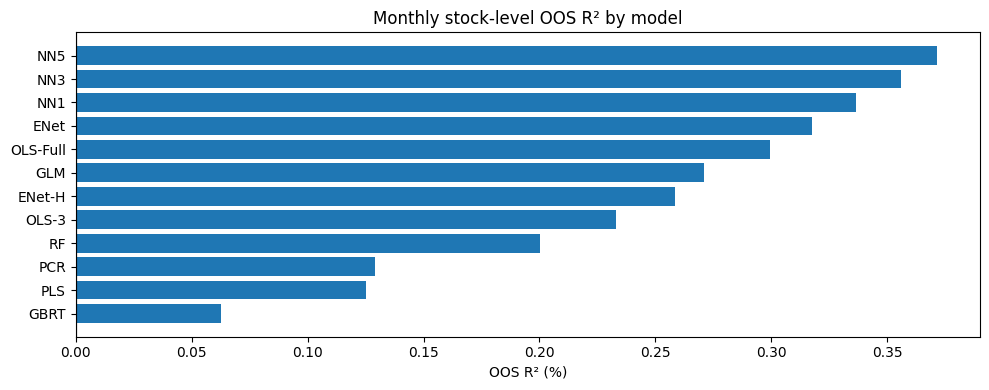

In [12]:
# ====================================================
# Paper Table 1-style stock-level predictive performance
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

MODEL_PLOT_ORDER = [
    "OLS-3", "OLS-Full", "PLS", "PCR", "ENet", "ENet-H",
    "GLM", "RF", "GBRT", "NN1", "NN3", "NN5",
]


def available_model_order(values):
    """Keep paper-like ordering while allowing the notebook to run with any subset of models."""
    values = [str(value) for value in values if pd.notna(value)]
    ordered = [model for model in MODEL_PLOT_ORDER if model in set(values)]
    extras = sorted(model for model in values if model not in set(ordered))
    return ordered + extras


def oos_r2_percent(actual, predicted):
    """Out-of-sample R² relative to the paper's zero-return benchmark forecast."""
    actual = pd.to_numeric(actual, errors="coerce").to_numpy(dtype="float64")
    predicted = pd.to_numeric(predicted, errors="coerce").to_numpy(dtype="float64")
    valid = np.isfinite(actual) & np.isfinite(predicted)
    if valid.sum() == 0:
        return np.nan
    numerator = np.sum((actual[valid] - predicted[valid]) ** 2)
    denominator = np.sum(actual[valid] ** 2)
    if denominator == 0:
        return np.nan
    return 100 * (1 - numerator / denominator)


def stock_r2_by_group(predictions, group_cols, actual_col="ret_excess", predicted_col="prediction"):
    """Compute stock-level R² for each group without changing the underlying prediction panel."""
    rows = []
    for keys, group in predictions.groupby(group_cols, observed=True, sort=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row["r2_oos_pct"] = oos_r2_percent(group[actual_col], group[predicted_col])
        row["n_obs"] = group[[actual_col, predicted_col]].dropna().shape[0]
        rows.append(row)
    return pd.DataFrame(rows)


def plot_heatmap_from_pivot(pivot, title, cmap="RdYlGn"):
    """Plot a compact heatmap from a model-by-column table."""
    if pivot.empty:
        print(f"No data available for {title}.")
        return
    data = pivot.to_numpy(dtype="float64")
    finite = data[np.isfinite(data)]
    if finite.size:
        vmax = np.nanpercentile(np.abs(finite), 95)
        vmax = max(vmax, 0.25)
    else:
        vmax = 1.0
    fig, ax = plt.subplots(figsize=(max(10, 0.35 * pivot.shape[1]), max(4, 0.35 * pivot.shape[0])))
    image = ax.imshow(data, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel(pivot.columns.name or "")
    ax.set_ylabel(pivot.index.name or "")
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns, rotation=90)
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)
    fig.colorbar(image, ax=ax, label="OOS R² (%)")
    fig.tight_layout()
    plt.show()


if "stock_predictions" not in globals():
    print("Run Step 18 first so `stock_predictions` exists.")
else:
    required_cols = {"model", "date", "permno", "me", "ret_excess", "prediction"}
    missing_cols = required_cols.difference(stock_predictions.columns)
    if missing_cols:
        raise ValueError(f"stock_predictions is missing required columns: {sorted(missing_cols)}")

    # Use the complete stock-level panel so ENet-H appears in the Table 1-style outputs.
    table1_predictions = stock_predictions

    stock_r2_all = stock_r2_by_group(table1_predictions, ["model"])
    stock_r2_all["model"] = pd.Categorical(
        stock_r2_all["model"],
        categories=available_model_order(stock_r2_all["model"]),
        ordered=True,
    )
    stock_r2_all = stock_r2_all.sort_values("model").reset_index(drop=True)

    print("Table 1-style monthly stock-level R², full OOS panel:")
    display(stock_r2_all.round({"r2_oos_pct": 4}))

    # The paper also reports top-1,000 and bottom-1,000 stocks by market value.
    # Because every model shares the same test panel, build those monthly buckets once
    # from a single reference model, then merge the bucket keys into the full panel.
    INCLUDE_TABLE1_SIZE_BUCKETS = True
    if INCLUDE_TABLE1_SIZE_BUCKETS:
        reference_model = available_model_order(table1_predictions["model"].dropna().unique())[0]
        size_source = table1_predictions.loc[
            table1_predictions["model"].eq(reference_model), ["date", "permno", "me"]
        ].dropna(subset=["date", "permno", "me"]).copy()
        size_source["me_rank_desc"] = size_source.groupby("date", observed=True)["me"].rank(
            method="first", ascending=False
        )
        size_source["n_stocks_in_month"] = size_source.groupby("date", observed=True)["permno"].transform("count")

        top_1000_keys = size_source.loc[
            size_source["me_rank_desc"].le(1000), ["date", "permno"]
        ].drop_duplicates()
        bottom_1000_keys = size_source.loc[
            size_source["me_rank_desc"].gt(size_source["n_stocks_in_month"] - 1000), ["date", "permno"]
        ].drop_duplicates()

        sample_frames = [stock_r2_all.assign(sample="All stocks")]
        core_cols = ["model", "date", "permno", "ret_excess", "prediction"]
        for sample_name, keys in [("Top 1,000 by ME", top_1000_keys), ("Bottom 1,000 by ME", bottom_1000_keys)]:
            sample_panel = table1_predictions[core_cols].merge(keys, on=["date", "permno"], how="inner")
            sample_r2 = stock_r2_by_group(sample_panel, ["model"]).assign(sample=sample_name)
            sample_frames.append(sample_r2)
            del sample_panel

        table1_like_r2 = pd.concat(sample_frames, ignore_index=True)
        table1_like_r2["model"] = pd.Categorical(
            table1_like_r2["model"],
            categories=available_model_order(table1_like_r2["model"]),
            ordered=True,
        )
        table1_like_r2 = table1_like_r2.sort_values(["sample", "model"]).reset_index(drop=True)
        table1_like_pivot = table1_like_r2.pivot(index="sample", columns="model", values="r2_oos_pct")

        print("Table 1-style R² by market-equity subsample:")
        display(table1_like_pivot.round(4))

    fig, ax = plt.subplots(figsize=(10, 4))
    bar_data = stock_r2_all.sort_values("r2_oos_pct", ascending=True)
    ax.barh(bar_data["model"].astype(str), bar_data["r2_oos_pct"])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Monthly stock-level OOS R² by model")
    ax.set_xlabel("OOS R² (%)")
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()



In [7]:
# ====================================================
# Paper Table 3-style Diebold-Mariano tests
# ====================================================
import math
import numpy as np
import pandas as pd

from IPython.display import display

# The PCR/PLS notebook used a Newey-West lag of 6 for the panel DM test.
# This cell keeps that convention for the all-model monthly comparison.
DM_NEWEY_WEST_LAG = 6
DM_INDIVIDUAL_5PCT_CUTOFF = 1.96
# The paper states that the 5% Bonferroni critical value for 12-way comparisons is 2.64.
DM_BONFERRONI_12WAY_CUTOFF = 2.64
DM_MODEL_ORDER = [
    "OLS-Full", "OLS-3", "PLS", "PCR", "ENet", "ENet-H",
    "GLM", "RF", "GBRT", "NN1", "NN3", "NN5",
]


def newey_west_se_of_mean(x, lag=DM_NEWEY_WEST_LAG):
    """Newey-West standard error for the mean of a single monthly time series."""
    x = np.asarray(x, dtype="float64")
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 2:
        return np.nan
    lag = min(int(lag), n - 1)
    centered = x - x.mean()
    long_run_variance = float(np.sum(centered ** 2)) / n
    for this_lag in range(1, lag + 1):
        weight = 1.0 - this_lag / (lag + 1.0)
        covariance = float(np.sum(centered[this_lag:] * centered[:-this_lag])) / n
        long_run_variance += 2.0 * weight * covariance
    return float(np.sqrt(max(long_run_variance, 0.0) / n))


def normal_two_sided_pvalue(stat):
    """Two-sided standard normal p-value without requiring scipy."""
    if not np.isfinite(stat):
        return np.nan
    return math.erfc(abs(float(stat)) / math.sqrt(2.0))


def format_dm_stat(stat):
    """Format one DM statistic with text-safe significance markers.

    The paper uses bold for individual 5% significance and an asterisk for the
    12-way Bonferroni threshold. Plain notebook tables do not show bold reliably,
    so this table uses + for individual 5% significance and * for Bonferroni.
    """
    if pd.isna(stat):
        return ""
    abs_stat = abs(float(stat))
    if abs_stat > DM_BONFERRONI_12WAY_CUTOFF:
        marker = "*"
    elif abs_stat > DM_INDIVIDUAL_5PCT_CUTOFF:
        marker = "+"
    else:
        marker = ""
    return f"{float(stat):.2f}{marker}"


def paper_style_upper_triangle(matrix, formatter=format_dm_stat):
    """Keep the upper triangle, matching the layout of Table 3 in the paper."""
    out = pd.DataFrame("", index=matrix.index, columns=matrix.columns)
    for row_idx, row_model in enumerate(matrix.index):
        for col_idx, col_model in enumerate(matrix.columns):
            if col_idx > row_idx:
                out.loc[row_model, col_model] = formatter(matrix.loc[row_model, col_model])
    return out


def compute_monthly_model_squared_errors(predictions, model_order):
    """Compute the cross-sectional average squared prediction error for each model-month.

    GKX adapt the Diebold-Mariano test to the stock panel by first averaging the
    squared-error difference across stocks within each month. Because all models in
    `stock_predictions` have been normalized to the same stock-month test panel, the
    monthly difference between two models is simply MSE(row model) - MSE(column model).
    """
    frames = []
    required_cols = {"model", "date", "ret_excess", "prediction"}
    missing_cols = required_cols.difference(predictions.columns)
    if missing_cols:
        raise ValueError(f"stock_predictions is missing required columns: {sorted(missing_cols)}")

    available = set(predictions["model"].dropna().astype(str).unique())
    for model_name in [model for model in model_order if model in available]:
        model_panel = predictions.loc[
            predictions["model"].astype(str).eq(model_name),
            ["date", "ret_excess", "prediction"],
        ].dropna(subset=["date", "ret_excess", "prediction"])
        squared_error = (
            model_panel["ret_excess"].to_numpy(dtype="float64")
            - model_panel["prediction"].to_numpy(dtype="float64")
        ) ** 2
        monthly = (
            pd.DataFrame({"date": model_panel["date"].to_numpy(), "squared_error": squared_error})
            .groupby("date", observed=True)
            .agg(mean_squared_error=("squared_error", "mean"), n_obs=("squared_error", "size"))
            .reset_index()
        )
        monthly["model"] = model_name
        frames.append(monthly)
        print(f"Prepared monthly squared errors for {model_name}: {monthly['date'].nunique()} months")

    if not frames:
        return pd.DataFrame(columns=["date", "mean_squared_error", "n_obs", "model"])
    return pd.concat(frames, ignore_index=True)


if "stock_predictions" not in globals():
    print("Run Step 18 first so `stock_predictions` exists.")
else:
    # Keep only models that are actually available in the normalized panel.
    dm_model_order = [model for model in DM_MODEL_ORDER if model in set(stock_predictions["model"].dropna().astype(str).unique())]
    missing_for_dm = [model for model in DM_MODEL_ORDER if model not in dm_model_order]
    if missing_for_dm:
        print(f"Skipping models not present in stock_predictions: {missing_for_dm}")

    dm_monthly_loss = compute_monthly_model_squared_errors(stock_predictions, dm_model_order)
    dm_loss_pivot = (
        dm_monthly_loss
        .pivot(index="date", columns="model", values="mean_squared_error")
        .reindex(columns=dm_model_order)
        .sort_index()
    )
    dm_obs_count_pivot = (
        dm_monthly_loss
        .pivot(index="date", columns="model", values="n_obs")
        .reindex(columns=dm_model_order)
        .sort_index()
    )

    print("Monthly observation-count audit for the DM test:")
    dm_count_audit = dm_obs_count_pivot.agg(["min", "max", "mean"]).T
    display(dm_count_audit.round({"mean": 1}))

    dm_stat_matrix = pd.DataFrame(np.nan, index=dm_model_order, columns=dm_model_order, dtype="float64")
    dm_pvalue_matrix = pd.DataFrame(np.nan, index=dm_model_order, columns=dm_model_order, dtype="float64")
    dm_pairwise_rows = []

    for row_model in dm_model_order:
        for column_model in dm_model_order:
            if row_model == column_model:
                continue
            # Positive d_t means the column model has lower average squared error than the row model.
            monthly_diff = (dm_loss_pivot[row_model] - dm_loss_pivot[column_model]).dropna().to_numpy(dtype="float64")
            mean_diff = float(np.mean(monthly_diff)) if len(monthly_diff) else np.nan
            se_nw = newey_west_se_of_mean(monthly_diff, lag=DM_NEWEY_WEST_LAG)
            dm_stat = mean_diff / se_nw if np.isfinite(se_nw) and se_nw > 0 else np.nan
            p_value = normal_two_sided_pvalue(dm_stat)

            dm_stat_matrix.loc[row_model, column_model] = dm_stat
            dm_pvalue_matrix.loc[row_model, column_model] = p_value
            dm_pairwise_rows.append({
                "row_model": row_model,
                "column_model": column_model,
                "n_months": len(monthly_diff),
                "mean_loss_row_minus_column": mean_diff,
                "nw_se_mean_loss_difference": se_nw,
                "dm_stat": dm_stat,
                "p_value": p_value,
                "column_model_better": bool(mean_diff > 0) if np.isfinite(mean_diff) else False,
                "significant_individual_5pct": bool(abs(dm_stat) > DM_INDIVIDUAL_5PCT_CUTOFF) if np.isfinite(dm_stat) else False,
                "significant_bonferroni_12way": bool(abs(dm_stat) > DM_BONFERRONI_12WAY_CUTOFF) if np.isfinite(dm_stat) else False,
            })

    dm_pairwise_results = pd.DataFrame(dm_pairwise_rows)
    dm_table3_stats = dm_stat_matrix.round(4)
    dm_table3_pvalues = dm_pvalue_matrix.round(4)
    dm_table3_paper_style = paper_style_upper_triangle(dm_stat_matrix)

    print("Table 3-style Diebold-Mariano statistics for monthly stock-level OOS predictions:")
    print("Rows are benchmark models; columns are comparison models. Positive means the column model has lower squared error.")
    print(f"Newey-West lag: {DM_NEWEY_WEST_LAG}.")
    print(f"+ marks individual 5% significance, |DM| > {DM_INDIVIDUAL_5PCT_CUTOFF:.2f}.")
    print(f"* marks the paper's 12-way Bonferroni threshold, |DM| > {DM_BONFERRONI_12WAY_CUTOFF:.2f}.")
    display(dm_table3_paper_style)

    print("Pairwise DM test details, long format:")
    display(
        dm_pairwise_results
        .sort_values(["row_model", "column_model"])
        .round({
            "mean_loss_row_minus_column": 8,
            "nw_se_mean_loss_difference": 8,
            "dm_stat": 4,
            "p_value": 4,
        })
    )


Prepared monthly squared errors for OLS-Full: 420 months
Prepared monthly squared errors for OLS-3: 420 months
Prepared monthly squared errors for PLS: 420 months
Prepared monthly squared errors for PCR: 420 months
Prepared monthly squared errors for ENet: 420 months
Prepared monthly squared errors for ENet-H: 420 months
Prepared monthly squared errors for GLM: 420 months
Prepared monthly squared errors for RF: 420 months
Prepared monthly squared errors for GBRT: 420 months
Prepared monthly squared errors for NN1: 420 months
Prepared monthly squared errors for NN3: 420 months
Prepared monthly squared errors for NN5: 420 months
Monthly observation-count audit for the DM test:


,min,max,mean
model,,,
OLS-Full,3549.0,7397.0,5087.9
OLS-3,3549.0,7397.0,5087.9
PLS,3549.0,7397.0,5087.9
PCR,3549.0,7397.0,5087.9
ENet,3549.0,7397.0,5087.9
ENet-H,3549.0,7397.0,5087.9
GLM,3549.0,7397.0,5087.9
RF,3549.0,7397.0,5087.9
GBRT,3549.0,7397.0,5087.9


Table 3-style Diebold-Mariano statistics for monthly stock-level OOS predictions:
Rows are benchmark models; columns are comparison models. Positive means the column model has lower squared error.
Newey-West lag: 6.
+ marks individual 5% significance, |DM| > 1.96.
* marks the paper's 12-way Bonferroni threshold, |DM| > 2.64.


,OLS-Full,OLS-3,PLS,PCR,ENet,ENet-H,GLM,RF,GBRT,NN1,NN3,NN5
OLS-Full,,-1.17,-1.75,-1.70,1.23,-0.55,-0.25,-0.65,-2.31+,0.70,0.85,1.07
OLS-3,,,-1.26,-1.24,2.10+,0.51,0.55,-0.14,-1.87,1.33,1.23,1.49
PLS,,,,0.37,2.12+,1.76,1.34,0.99,0.02,1.91,2.01+,2.15+
PCR,,,,,2.06+,1.69,1.30,0.95,-0.04,1.82,1.88,2.02+
ENet,,,,,,-1.72,-0.77,-1.02,-2.94*,0.22,0.34,0.64
ENet-H,,,,,,,0.14,-0.40,-2.77*,1.10,1.11,1.26
GLM,,,,,,,,-0.72,-2.07+,1.36,1.13,1.44
RF,,,,,,,,,-1.39,1.41,1.24,1.74
GBRT,,,,,,,,,,2.64*,2.40+,2.39+
NN1,,,,,,,,,,,0.11,0.59


Pairwise DM test details, long format:


,row_model,column_model,n_months,mean_loss_row_minus_column,nw_se_mean_loss_difference,dm_stat,p_value,column_model_better,significant_individual_5pct,significant_bonferroni_12way
48,ENet,ENet-H,420,-0.000023,0.000013,-1.7187,0.0857,False,False,False
51,ENet,GBRT,420,-0.000084,0.000028,-2.9405,0.0033,False,True,True
49,ENet,GLM,420,-0.000019,0.000025,-0.7748,0.4385,False,False,False
52,ENet,NN1,420,0.000006,0.000028,0.2240,0.8228,True,False,False
53,ENet,NN3,420,0.000009,0.000026,0.3363,0.7367,True,False,False
...,...,...,...,...,...,...,...,...,...,...
87,RF,NN5,420,0.000055,0.000032,1.7397,0.0819,True,False,False
78,RF,OLS-3,420,0.000004,0.000030,0.1399,0.8887,True,False,False
77,RF,OLS-Full,420,0.000022,0.000034,0.6535,0.5134,True,False,False
80,RF,PCR,420,-0.000046,0.000049,-0.9503,0.3420,False,False,False


In [ ]:
# ====================================================
# Paper Table 5-style portfolio R²
# ====================================================
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


if "portfolio_r2_table" not in globals():
    print("Run Step 20 first so `portfolio_r2_table` exists.")
else:
    table5_like_r2 = portfolio_r2_table.copy()
    table5_like_r2["model"] = pd.Categorical(
        table5_like_r2["model"],
        categories=available_model_order(table5_like_r2["model"]),
        ordered=True,
    )

    common_portfolio_ids = [pid for pid in ["MKT", "SMB", "HML", "RMW", "CMA", "UMD"] if pid in set(table5_like_r2["portfolio_id"])]
    table5_common = table5_like_r2.loc[table5_like_r2["portfolio_id"].isin(common_portfolio_ids)].copy()
    table5_common_pivot = table5_common.pivot(index="display_name", columns="model", values="r2_oos_pct")

    print("Table 5-style monthly portfolio-level OOS R² for common portfolios:")
    display(table5_common_pivot.round(4))

    plot_heatmap_from_pivot(
        table5_common_pivot,
        "Monthly portfolio-level OOS R²: common factor portfolios",
    )

    # The full Table 5 also includes 24 long-only 2-by-3 component portfolios.
    # This second heatmap uses whatever Step 20 wrote under the current forecast mode.
    table5_full_pivot = (
        table5_like_r2
        .pivot(index="display_name", columns="model", values="r2_oos_pct")
        .loc[:, [model for model in available_model_order(table5_like_r2["model"].dropna().unique()) if model in table5_like_r2["model"].astype(str).unique()]]
    )
    plot_heatmap_from_pivot(
        table5_full_pivot,
        f"Monthly portfolio-level OOS R²: {PORTFOLIO_FORECAST_MODE} portfolio set",
    )



Built decile returns for OLS-3: 420 months
Built decile returns for OLS-Full: 420 months
Built decile returns for PLS: 420 months
Built decile returns for PCR: 420 months
Built decile returns for ENet: 420 months
Built decile returns for ENet-H: 420 months
Built decile returns for GLM: 420 months
Built decile returns for RF: 420 months
Built decile returns for GBRT: 420 months
Built decile returns for NN1: 420 months
Built decile returns for NN3: 420 months
Built decile returns for NN5: 420 months
Table 7-style prediction-sorted value-weighted portfolio stats:


,model,decile,Pred_monthly_pct,Avg_monthly_pct,SD_monthly_pct,n_months,SR_annualized
0,OLS-3,1,-0.2701,0.6990,5.3185,420,0.4553
1,OLS-3,2,0.0616,0.7732,4.4524,420,0.6016
2,OLS-3,3,0.2488,0.8103,4.7230,420,0.5943
3,OLS-3,4,0.4066,0.7808,4.7692,420,0.5671
4,OLS-3,5,0.5526,0.8993,4.7742,420,0.6525
...,...,...,...,...,...,...,...
127,NN5,7,0.8054,0.8833,4.6215,420,0.6621
128,NN5,8,0.9097,0.9554,4.8008,420,0.6894
129,NN5,9,1.0604,1.0746,5.1523,420,0.7225
130,NN5,10,1.5924,1.4602,6.5672,420,0.7702


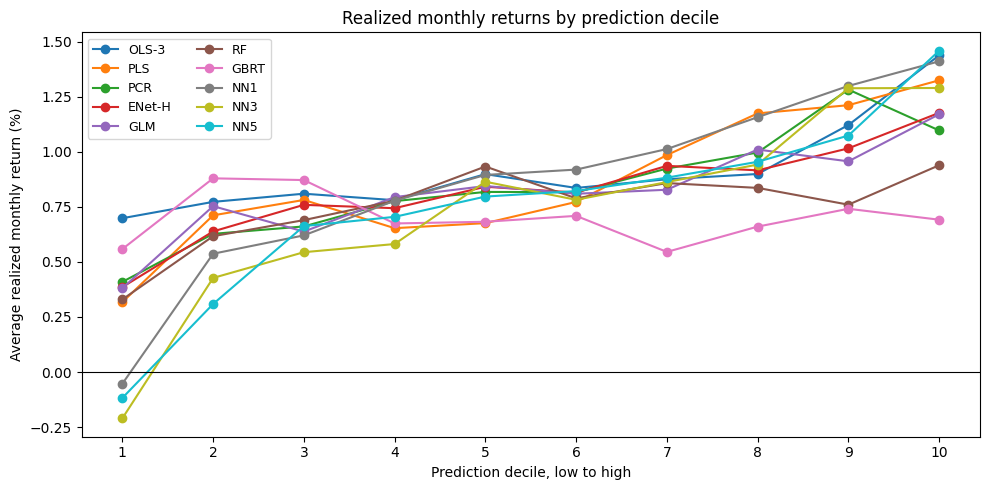

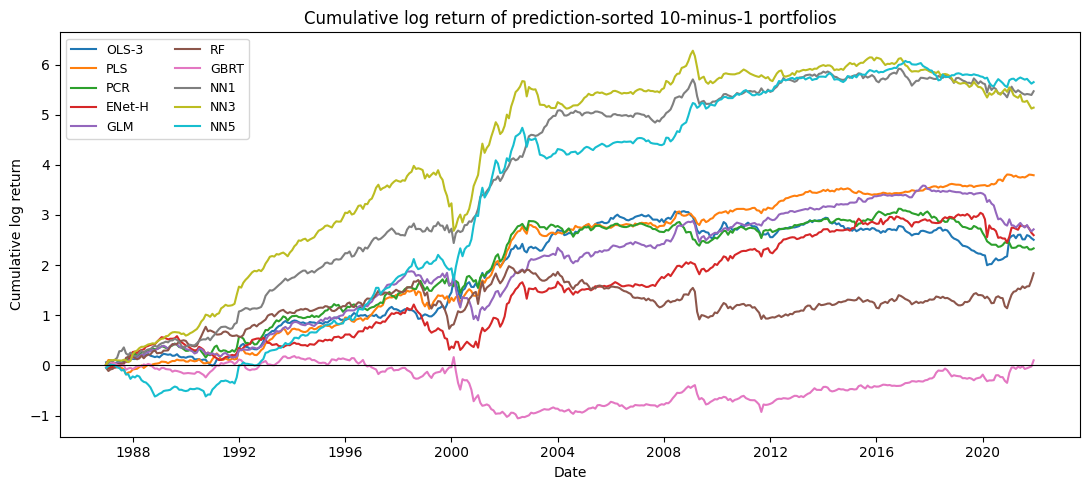

In [9]:
# ====================================================
# Paper Table 7 / Figure 9-style prediction-sorted decile portfolios
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# This cell is heavier than the R² cells because it sorts millions of stock-month forecasts.
# I keep it True to build all available model decile portfolios; while iterating,
# I can use a smaller subset such as ["NN3", "GBRT", "RF"].
RUN_PREDICTION_DECILE_PORTFOLIOS = True
DECILE_MODELS_TO_RUN = None  # None means every model in stock_predictions, in paper-like order.
FIGURE9_MODELS_TO_PLOT = ["OLS-3", "PLS", "PCR", "ENet-H", "GLM", "RF", "GBRT", "NN1", "NN3", "NN5"]


def build_prediction_decile_returns(predictions, model_names=None, n_deciles=10, weight_col="weight_me"):
    """Sort stocks into forecast deciles each month and compute value-weighted returns.

    The paper forms deciles from one-month-ahead OOS stock predictions, then uses
    ex ante market-equity weights inside each decile. The `weight_me` column was built
    in Step 18 from prior-month CRSP market equity, so the weights are known before
    the realized return month.
    """
    required_cols = {"model", "date", "permno", "prediction", "ret_excess", weight_col}
    missing_cols = required_cols.difference(predictions.columns)
    if missing_cols:
        raise ValueError(f"stock_predictions is missing required columns: {sorted(missing_cols)}")

    if model_names is None:
        model_names = available_model_order(predictions["model"].dropna().unique())
    else:
        model_names = [model for model in model_names if model in set(predictions["model"].astype(str).unique())]

    monthly_frames = []
    cols = ["model", "date", "permno", "prediction", "ret_excess", weight_col]

    for model_name in model_names:
        model_panel = predictions.loc[predictions["model"].astype(str).eq(model_name), cols].copy()
        model_panel = model_panel.dropna(subset=["date", "prediction", "ret_excess", weight_col])
        model_panel = model_panel.loc[model_panel[weight_col].gt(0)].copy()
        if model_panel.empty:
            print(f"Skipping {model_name}: no usable rows after removing missing weights/returns.")
            continue

        # Rank forecasts within each month. Converting ranks into integer buckets gives
        # qcut-like equal-count deciles without the duplicate-edge problems that happen
        # when many stocks share very similar forecasts.
        model_panel["forecast_rank"] = model_panel.groupby("date", observed=True)["prediction"].rank(method="first")
        model_panel["n_in_month"] = model_panel.groupby("date", observed=True)["prediction"].transform("count")
        model_panel = model_panel.loc[model_panel["n_in_month"].ge(n_deciles)].copy()
        model_panel["decile"] = (
            np.floor((model_panel["forecast_rank"] - 1) * n_deciles / model_panel["n_in_month"]).astype("int16") + 1
        )

        model_panel["weighted_prediction_sum"] = model_panel["prediction"] * model_panel[weight_col]
        model_panel["weighted_return_sum"] = model_panel["ret_excess"] * model_panel[weight_col]

        monthly = (
            model_panel
            .groupby(["model", "date", "decile"], observed=True)
            .agg(
                weight_sum=(weight_col, "sum"),
                predicted_weighted_sum=("weighted_prediction_sum", "sum"),
                realized_weighted_sum=("weighted_return_sum", "sum"),
                n_stocks=("permno", "nunique"),
            )
            .reset_index()
        )
        monthly["predicted_return"] = monthly["predicted_weighted_sum"] / monthly["weight_sum"]
        monthly["realized_return"] = monthly["realized_weighted_sum"] / monthly["weight_sum"]
        monthly_frames.append(monthly[["model", "date", "decile", "predicted_return", "realized_return", "n_stocks", "weight_sum"]])
        print(f"Built decile returns for {model_name}: {monthly['date'].nunique()} months")

    if not monthly_frames:
        return pd.DataFrame(columns=["model", "date", "decile", "predicted_return", "realized_return", "n_stocks", "weight_sum"])
    return pd.concat(monthly_frames, ignore_index=True)


def summarize_prediction_deciles(decile_monthly):
    """Create the Table 7-style Pred / Avg / SD / Sharpe summary."""
    decile_stats = (
        decile_monthly
        .groupby(["model", "decile"], observed=True)
        .agg(
            Pred_monthly_pct=("predicted_return", lambda x: 100 * x.mean()),
            Avg_monthly_pct=("realized_return", lambda x: 100 * x.mean()),
            SD_monthly_pct=("realized_return", lambda x: 100 * x.std(ddof=1)),
            n_months=("realized_return", "count"),
        )
        .reset_index()
    )
    decile_stats["SR_annualized"] = np.sqrt(12) * (
        decile_stats["Avg_monthly_pct"] / decile_stats["SD_monthly_pct"]
    )

    low = decile_monthly.loc[decile_monthly["decile"].eq(1), ["model", "date", "predicted_return", "realized_return"]]
    high = decile_monthly.loc[decile_monthly["decile"].eq(10), ["model", "date", "predicted_return", "realized_return"]]
    spread = high.merge(low, on=["model", "date"], suffixes=("_high", "_low"))
    spread["decile"] = "H-L"
    spread["predicted_return"] = spread["predicted_return_high"] - spread["predicted_return_low"]
    spread["realized_return"] = spread["realized_return_high"] - spread["realized_return_low"]

    spread_stats = (
        spread
        .groupby(["model", "decile"], observed=True)
        .agg(
            Pred_monthly_pct=("predicted_return", lambda x: 100 * x.mean()),
            Avg_monthly_pct=("realized_return", lambda x: 100 * x.mean()),
            SD_monthly_pct=("realized_return", lambda x: 100 * x.std(ddof=1)),
            n_months=("realized_return", "count"),
        )
        .reset_index()
    )
    spread_stats["SR_annualized"] = np.sqrt(12) * (
        spread_stats["Avg_monthly_pct"] / spread_stats["SD_monthly_pct"]
    )
    return pd.concat([decile_stats, spread_stats], ignore_index=True), spread


def max_drawdown_pct(monthly_returns):
    """Maximum drawdown from cumulative log returns, matching the paper's definition."""
    returns = pd.to_numeric(monthly_returns, errors="coerce").dropna().clip(lower=-0.99)
    if returns.empty:
        return np.nan
    cumulative_log_return = np.log1p(returns).cumsum()
    drawdown = cumulative_log_return.cummax() - cumulative_log_return
    return 100 * drawdown.max()


if "stock_predictions" not in globals():
    print("Run Step 18 first so `stock_predictions` exists.")
elif not RUN_PREDICTION_DECILE_PORTFOLIOS:
    print("Set RUN_PREDICTION_DECILE_PORTFOLIOS = True when you want to build decile portfolios.")
else:
    if DECILE_MODELS_TO_RUN is None:
        DECILE_MODELS_TO_RUN = available_model_order(stock_predictions["model"].dropna().unique())

    decile_monthly_returns = build_prediction_decile_returns(
        stock_predictions,
        model_names=DECILE_MODELS_TO_RUN,
        n_deciles=10,
        weight_col="weight_me",
    )
    decile_portfolio_stats, decile_spread_monthly = summarize_prediction_deciles(decile_monthly_returns)
    decile_portfolio_stats["model"] = pd.Categorical(
        decile_portfolio_stats["model"],
        categories=available_model_order(decile_portfolio_stats["model"].dropna().unique()),
        ordered=True,
    )
    decile_portfolio_stats["decile_order"] = decile_portfolio_stats["decile"].apply(
        lambda value: 11 if str(value) == "H-L" else int(value)
    )
    decile_portfolio_stats = (
        decile_portfolio_stats
        .sort_values(["model", "decile_order"])
        .drop(columns="decile_order")
        .reset_index(drop=True)
    )

    print("Table 7-style prediction-sorted value-weighted portfolio stats:")
    display(decile_portfolio_stats.round({
        "Pred_monthly_pct": 4,
        "Avg_monthly_pct": 4,
        "SD_monthly_pct": 4,
        "SR_annualized": 4,
    }))

    selected_for_plot = [model for model in FIGURE9_MODELS_TO_PLOT if model in set(decile_portfolio_stats["model"].astype(str))]
    decile_only = decile_portfolio_stats.loc[decile_portfolio_stats["decile"].ne("H-L")].copy()
    decile_only["decile"] = decile_only["decile"].astype(int)

    fig, ax = plt.subplots(figsize=(10, 5))
    for model_name in selected_for_plot:
        model_stats = decile_only.loc[decile_only["model"].astype(str).eq(model_name)].sort_values("decile")
        ax.plot(model_stats["decile"], model_stats["Avg_monthly_pct"], marker="o", label=model_name)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Realized monthly returns by prediction decile")
    ax.set_xlabel("Prediction decile, low to high")
    ax.set_ylabel("Average realized monthly return (%)")
    ax.set_xticks(range(1, 11))
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(11, 5))
    for model_name in selected_for_plot:
        model_spread = decile_spread_monthly.loc[
            decile_spread_monthly["model"].astype(str).eq(model_name)
        ].sort_values("date")
        cumulative = np.log1p(model_spread["realized_return"].clip(lower=-0.99)).cumsum()
        ax.plot(model_spread["date"], cumulative, label=model_name)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Cumulative log return of prediction-sorted 10-minus-1 portfolios")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative log return")
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    plt.show()


In [10]:
# ====================================================
# Paper Table 8-style drawdowns, turnover, and risk-adjusted performance
# ====================================================
from pathlib import Path
import numpy as np
import pandas as pd

from IPython.display import display

# Table 8 is built from the same monthly one-month-ahead stock forecasts used above.
# For each model and month, I sort stocks into ten forecast deciles, buy decile 10,
# short decile 1, and then compute risk diagnostics for that 10-minus-1 portfolio.
RUN_TABLE8_DIAGNOSTICS = True
TABLE8_MODELS_TO_RUN = None  # None means every model in stock_predictions, in paper-like order.
TABLE8_N_DECILES = 10
TABLE8_FACTOR_CANDIDATES = [
    Path("/Users/julianreynolds/Project/data/ff5_mom.csv"),
    Path("/Users/julianreynolds/Project/data/FF5_Mom.csv"),
    Path("/Users/julianreynolds/Project/data/Results/ff5_mom.csv"),
    Path("/Users/julianreynolds/Project/data/Results/pcr_pls/ff5_mom.csv"),
]


def table8_annualized_sharpe(monthly_returns):
    """Annualized Sharpe ratio from monthly long-short returns."""
    returns = pd.to_numeric(monthly_returns, errors="coerce").dropna()
    sd = returns.std(ddof=1)
    if returns.empty or sd == 0 or pd.isna(sd):
        return np.nan
    return np.sqrt(12) * returns.mean() / sd


def table8_max_drawdown_pct(monthly_returns):
    """Paper-style maximum drawdown: largest fall in cumulative log return, in percent."""
    returns = pd.to_numeric(monthly_returns, errors="coerce").dropna().clip(lower=-0.99)
    if returns.empty:
        return np.nan
    cumulative_log_return = np.log1p(returns).cumsum()
    drawdown = cumulative_log_return.cummax() - cumulative_log_return
    return 100 * drawdown.max()


def table8_average_turnover(holdings):
    """Average monthly turnover using the paper's return-drift formula.

    The formula compares the next month's target weights with the previous month's
    weights after they have drifted with realized stock returns. For a 10-minus-1
    spread, top-decile weights sum to +1 and bottom-decile weights sum to -1.
    """
    if holdings.empty:
        return np.nan

    holdings = holdings.sort_values(["date", "permno"])
    turnovers = []
    previous = None

    for _, current in holdings.groupby("date", sort=True, observed=True):
        current_weights = current.set_index("permno")["signed_weight"]
        if previous is not None:
            previous_indexed = previous.set_index("permno")
            previous_weights = previous_indexed["signed_weight"]
            previous_returns = previous_indexed["turnover_return"]
            portfolio_return = (previous_weights * previous_returns).sum()
            denominator = 1 + portfolio_return

            if np.isfinite(denominator) and abs(denominator) > 1e-12:
                drifted_weights = previous_weights * (1 + previous_returns) / denominator
                all_permnos = current_weights.index.union(drifted_weights.index)
                turnover = (
                    current_weights.reindex(all_permnos, fill_value=0.0)
                    - drifted_weights.reindex(all_permnos, fill_value=0.0)
                ).abs().sum()
                turnovers.append(turnover)

        previous = current[["permno", "signed_weight", "turnover_return"]].copy()

    if not turnovers:
        return np.nan
    return float(np.mean(turnovers))


def table8_build_spread_outputs(predictions, model_names=None, n_deciles=10, weight_col="weight_me"):
    """Create monthly 10-minus-1 returns and Table 8 diagnostics for VW and EW portfolios."""
    required_cols = {"model", "date", "permno", "prediction", "ret_excess", weight_col}
    missing_cols = required_cols.difference(predictions.columns)
    if missing_cols:
        raise ValueError(f"stock_predictions is missing required columns: {sorted(missing_cols)}")

    # Turnover ideally uses raw stock returns. If the normalized prediction files only
    # contain excess returns, I use ret_excess as the closest available return field.
    turnover_return_col = "ret" if "ret" in predictions.columns else "ret_excess"
    model_as_string = predictions["model"].astype(str)

    if model_names is None:
        model_names = available_model_order(model_as_string.dropna().unique())
    else:
        available = set(model_as_string.dropna().unique())
        model_names = [model for model in model_names if model in available]

    monthly_frames = []
    summary_rows = []
    base_cols = ["model", "date", "permno", "prediction", "ret_excess", weight_col, turnover_return_col]
    base_cols = list(dict.fromkeys(base_cols))

    for model_name in model_names:
        model_panel = predictions.loc[model_as_string.eq(model_name), base_cols].copy()
        model_panel = model_panel.dropna(subset=["date", "permno", "prediction", "ret_excess", weight_col, turnover_return_col])
        model_panel = model_panel.loc[model_panel[weight_col].gt(0)].copy()
        if model_panel.empty:
            print(f"Skipping {model_name}: no usable rows after removing missing weights/returns.")
            continue

        # These deciles match the Table 7/Figure 9 construction: equal-count forecast
        # buckets within each month, avoiding qcut duplicate-edge issues.
        model_panel["forecast_rank"] = model_panel.groupby("date", observed=True)["prediction"].rank(method="first")
        model_panel["n_in_month"] = model_panel.groupby("date", observed=True)["prediction"].transform("count")
        model_panel = model_panel.loc[model_panel["n_in_month"].ge(n_deciles)].copy()
        model_panel["decile"] = (
            np.floor((model_panel["forecast_rank"] - 1) * n_deciles / model_panel["n_in_month"]).astype("int16") + 1
        )
        spread_holdings = model_panel.loc[model_panel["decile"].isin([1, n_deciles])].copy()
        if spread_holdings.empty:
            print(f"Skipping {model_name}: no top/bottom decile holdings were formed.")
            continue

        spread_holdings["side"] = np.where(spread_holdings["decile"].eq(n_deciles), 1.0, -1.0)
        spread_holdings["turnover_return"] = pd.to_numeric(spread_holdings[turnover_return_col], errors="coerce")

        for weighting, base_weight_col in [("value weighted", weight_col), ("equally weighted", None)]:
            holdings = spread_holdings[["date", "permno", "decile", "side", "ret_excess", "turnover_return"]].copy()
            if base_weight_col is None:
                holdings["base_weight"] = 1.0
            else:
                holdings["base_weight"] = spread_holdings[base_weight_col].to_numpy(dtype="float64")

            holdings["leg_weight_sum"] = holdings.groupby(["date", "decile"], observed=True)["base_weight"].transform("sum")
            holdings = holdings.loc[holdings["leg_weight_sum"].gt(0)].copy()
            holdings["signed_weight"] = holdings["side"] * holdings["base_weight"] / holdings["leg_weight_sum"]
            holdings["weighted_return"] = holdings["signed_weight"] * holdings["ret_excess"]

            monthly = (
                holdings
                .groupby("date", observed=True)
                .agg(
                    realized_return=("weighted_return", "sum"),
                    n_positions=("permno", "nunique"),
                )
                .reset_index()
            )
            monthly["model"] = model_name
            monthly["weighting"] = weighting
            monthly_frames.append(monthly[["model", "weighting", "date", "realized_return", "n_positions"]])

            turnover = table8_average_turnover(holdings[["date", "permno", "signed_weight", "turnover_return"]])
            realized = monthly["realized_return"]
            summary_rows.append({
                "model": model_name,
                "weighting": weighting,
                "mean_return_pct": 100 * realized.mean(),
                "sd_monthly_pct": 100 * realized.std(ddof=1),
                "sr_annualized": table8_annualized_sharpe(realized),
                "max_dd_pct": table8_max_drawdown_pct(realized),
                "max_1m_loss_pct": -100 * realized.min(),
                "turnover_pct": 100 * turnover if pd.notna(turnover) else np.nan,
                "n_months": int(realized.notna().sum()),
            })

        print(f"Built Table 8 diagnostics for {model_name}: {spread_holdings['date'].nunique()} months")

    monthly_returns = (
        pd.concat(monthly_frames, ignore_index=True)
        if monthly_frames
        else pd.DataFrame(columns=["model", "weighting", "date", "realized_return", "n_positions"])
    )
    summary = pd.DataFrame(summary_rows)
    return summary, monthly_returns, turnover_return_col


def table8_factor_column_map(columns):
    """Map flexible FF factor column names onto the six factors used in the paper."""
    def clean(name):
        return ''.join(ch for ch in str(name).lower() if ch.isalnum())

    cleaned = {clean(col): col for col in columns}
    specs = {
        "mktrf": ["mktrf", "mktminusrf", "marketrf", "mkt"] ,
        "smb": ["smb"],
        "hml": ["hml"],
        "rmw": ["rmw"],
        "cma": ["cma"],
        "mom": ["mom", "umd", "momentum"],
    }
    output = {}
    for target, aliases in specs.items():
        for alias in aliases:
            if alias in cleaned:
                output[target] = cleaned[alias]
                break
    return output


def table8_parse_factor_dates(df):
    """Add a monthly Period column from common factor-file date formats."""
    date_candidates = [col for col in df.columns if str(col).lower() in {"date", "yyyymm", "month"}]
    if date_candidates:
        date_col = date_candidates[0]
    else:
        date_col = df.columns[0]

    raw = df[date_col]
    numeric_raw = pd.to_numeric(raw, errors="coerce")
    if numeric_raw.notna().mean() > 0.8 and numeric_raw.dropna().astype(int).astype(str).str.len().median() == 6:
        parsed = pd.to_datetime(numeric_raw.dropna().astype(int).astype(str), format="%Y%m")
        month = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")
        month.loc[parsed.index] = parsed
    else:
        month = pd.to_datetime(raw, errors="coerce")

    df = df.copy()
    df["month"] = month.dt.to_period("M")
    return df


def table8_load_ff5_mom_factors(candidate_paths):
    """Load FF5+Momentum factors if a local factor file is available."""
    for path in candidate_paths:
        path = Path(path)
        if not path.exists():
            continue
        factors = pd.read_csv(path)
        factors = table8_parse_factor_dates(factors)
        col_map = table8_factor_column_map(factors.columns)
        required = ["mktrf", "smb", "hml", "rmw", "cma", "mom"]
        missing = [col for col in required if col not in col_map]
        if missing:
            print(f"Found {path}, but it is missing factor columns: {missing}. Skipping factor regressions.")
            return None, path

        keep = ["month"] + [col_map[col] for col in required]
        factors = factors[keep].rename(columns={col_map[col]: col for col in required})
        factors = factors.dropna(subset=["month"] + required).copy()
        for col in required:
            factors[col] = pd.to_numeric(factors[col], errors="coerce")
        factors = factors.dropna(subset=required).copy()

        # Ken French-style files are usually in percent units, while our returns are decimals.
        if factors[required].abs().max().max() > 2:
            factors[required] = factors[required] / 100.0

        return factors, path

    return None, None


def table8_add_factor_adjustment(summary, monthly_returns, factor_candidates):
    """Add FF5+Mom alpha, t-stat, R², and IR when factor data is present."""
    factors, factor_path = table8_load_ff5_mom_factors(factor_candidates)
    summary = summary.copy()
    for col in ["ff5_mom_alpha_pct", "t_alpha", "factor_r2_pct", "information_ratio", "factor_n_months"]:
        summary[col] = np.nan

    if factors is None:
        print("No usable FF5+Momentum factor file found. Put one at data/ff5_mom.csv to fill the alpha, t-stat, R², and IR rows.")
        return summary, None

    import statsmodels.api as sm

    factor_cols = ["mktrf", "smb", "hml", "rmw", "cma", "mom"]
    returns = monthly_returns.copy()
    returns["month"] = pd.to_datetime(returns["date"]).dt.to_period("M")

    for idx, row in summary.iterrows():
        model_name = row["model"]
        weighting = row["weighting"]
        y_data = returns.loc[
            returns["model"].astype(str).eq(str(model_name)) & returns["weighting"].eq(weighting),
            ["month", "realized_return"],
        ]
        reg_data = y_data.merge(factors, on="month", how="inner").dropna(subset=["realized_return"] + factor_cols)
        if len(reg_data) < len(factor_cols) + 12:
            continue

        y = reg_data["realized_return"].astype(float)
        x = sm.add_constant(reg_data[factor_cols].astype(float), has_constant="add")
        fit = sm.OLS(y, x).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
        alpha = fit.params.get("const", np.nan)
        residual_sd = fit.resid.std(ddof=1)
        summary.loc[idx, "ff5_mom_alpha_pct"] = 100 * alpha
        summary.loc[idx, "t_alpha"] = fit.tvalues.get("const", np.nan)
        summary.loc[idx, "factor_r2_pct"] = 100 * fit.rsquared
        summary.loc[idx, "information_ratio"] = np.sqrt(12) * alpha / residual_sd if residual_sd and pd.notna(residual_sd) else np.nan
        summary.loc[idx, "factor_n_months"] = len(reg_data)

    print(f"Loaded FF5+Momentum factors from {factor_path}")
    return summary, factor_path


def table8_panel(summary, weighting, metrics):
    """Make a paper-like model-by-metric panel for one weighting scheme."""
    subset = summary.loc[summary["weighting"].eq(weighting)].copy()
    if subset.empty:
        return pd.DataFrame()
    subset["model"] = pd.Categorical(
        subset["model"],
        categories=available_model_order(subset["model"].dropna().unique()),
        ordered=True,
    )
    subset = subset.sort_values("model")
    panel = subset.set_index("model")[[col for _, col in metrics]].T
    panel.index = [label for label, _ in metrics]
    return panel


if "stock_predictions" not in globals():
    print("Run Step 18 first so `stock_predictions` exists.")
elif not RUN_TABLE8_DIAGNOSTICS:
    print("Set RUN_TABLE8_DIAGNOSTICS = True when you want to build the Table 8-style diagnostics.")
else:
    table8_summary_raw, table8_monthly_spread_returns, table8_turnover_return_col = table8_build_spread_outputs(
        stock_predictions,
        model_names=TABLE8_MODELS_TO_RUN,
        n_deciles=TABLE8_N_DECILES,
        weight_col="weight_me",
    )
    table8_summary, table8_factor_path = table8_add_factor_adjustment(
        table8_summary_raw,
        table8_monthly_spread_returns,
        TABLE8_FACTOR_CANDIDATES,
    )

    table8_summary["model"] = pd.Categorical(
        table8_summary["model"],
        categories=available_model_order(table8_summary["model"].dropna().unique()),
        ordered=True,
    )
    table8_summary = table8_summary.sort_values(["weighting", "model"]).reset_index(drop=True)

    print(f"Turnover drift used `{table8_turnover_return_col}` because that is the available stock-return column.")
    print("Table 8-style diagnostics, long format:")
    display(table8_summary.round({
        "mean_return_pct": 4,
        "sd_monthly_pct": 4,
        "sr_annualized": 4,
        "max_dd_pct": 4,
        "max_1m_loss_pct": 4,
        "turnover_pct": 4,
        "ff5_mom_alpha_pct": 4,
        "t_alpha": 4,
        "factor_r2_pct": 4,
        "information_ratio": 4,
        "factor_n_months": 0,
    }))

    drawdown_metrics = [
        ("Max DD(%)", "max_dd_pct"),
        ("Max 1M loss(%)", "max_1m_loss_pct"),
        ("Turnover(%)", "turnover_pct"),
    ]
    risk_metrics = [
        ("Mean ret.", "mean_return_pct"),
        ("FF5+Mom alpha", "ff5_mom_alpha_pct"),
        ("t(alpha)", "t_alpha"),
        ("R2", "factor_r2_pct"),
        ("IR", "information_ratio"),
    ]

    table8_drawdown_value_weighted = table8_panel(table8_summary, "value weighted", drawdown_metrics)
    table8_drawdown_equal_weighted = table8_panel(table8_summary, "equally weighted", drawdown_metrics)
    table8_risk_adjusted_value_weighted = table8_panel(table8_summary, "value weighted", risk_metrics)
    table8_risk_adjusted_equal_weighted = table8_panel(table8_summary, "equally weighted", risk_metrics)

    print("Drawdowns and turnover (value weighted):")
    display(table8_drawdown_value_weighted.round(2))
    print("Drawdowns and turnover (equally weighted):")
    display(table8_drawdown_equal_weighted.round(2))
    print("Risk-adjusted performance (value weighted):")
    display(table8_risk_adjusted_value_weighted.round(2))
    print("Risk-adjusted performance (equally weighted):")
    display(table8_risk_adjusted_equal_weighted.round(2))


Built Table 8 diagnostics for OLS-3: 420 months
Built Table 8 diagnostics for OLS-Full: 420 months
Built Table 8 diagnostics for PLS: 420 months
Built Table 8 diagnostics for PCR: 420 months
Built Table 8 diagnostics for ENet: 420 months
Built Table 8 diagnostics for ENet-H: 420 months
Built Table 8 diagnostics for GLM: 420 months
Built Table 8 diagnostics for RF: 420 months
Built Table 8 diagnostics for GBRT: 420 months
Built Table 8 diagnostics for NN1: 420 months
Built Table 8 diagnostics for NN3: 420 months
Built Table 8 diagnostics for NN5: 420 months
No usable FF5+Momentum factor file found. Put one at data/ff5_mom.csv to fill the alpha, t-stat, R², and IR rows.
Turnover drift used `ret_excess` because that is the available stock-return column.
Table 8-style diagnostics, long format:


,model,weighting,mean_return_pct,sd_monthly_pct,sr_annualized,max_dd_pct,max_1m_loss_pct,turnover_pct,n_months,ff5_mom_alpha_pct,t_alpha,factor_r2_pct,information_ratio,factor_n_months
0,OLS-3,equally weighted,1.2009,5.4445,0.7641,67.4359,30.3142,107.5296,420,NaN,NaN,NaN,NaN,NaN
1,OLS-Full,equally weighted,2.3452,5.0473,1.6095,60.4814,30.0947,268.2711,420,NaN,NaN,NaN,NaN,NaN
2,PLS,equally weighted,2.3500,4.4436,1.8319,28.5498,18.3385,203.0793,420,NaN,NaN,NaN,NaN,NaN
3,PCR,equally weighted,2.2742,4.6934,1.6785,35.5506,19.7719,232.3639,420,NaN,NaN,NaN,NaN,NaN
4,ENet,equally weighted,2.5752,6.4802,1.3766,91.3556,26.8894,268.3249,420,NaN,NaN,NaN,NaN,NaN
5,ENet-H,equally weighted,2.0637,5.7726,1.2384,99.5807,30.3767,275.1833,420,NaN,NaN,NaN,NaN,NaN
6,GLM,equally weighted,2.3020,4.5096,1.7683,86.3877,18.7945,241.1685,420,NaN,NaN,NaN,NaN,NaN
7,RF,equally weighted,2.7423,4.7479,2.0008,28.5480,14.1375,175.1374,420,NaN,NaN,NaN,NaN,NaN
8,GBRT,equally weighted,0.7042,4.0553,0.6015,129.1064,18.7945,150.5345,420,NaN,NaN,NaN,NaN,NaN
9,NN1,equally weighted,3.4669,5.0857,2.3614,21.9233,13.1861,262.7403,420,NaN,NaN,NaN,NaN,NaN


Drawdowns and turnover (value weighted):


model,OLS-3,OLS-Full,PLS,PCR,ENet,ENet-H,GLM,RF,GBRT,NN1,NN3,NN5
Max DD(%),107.84,61.35,39.93,81.45,102.80,90.62,97.88,106.31,124.17,57.09,129.55,63.32
Max 1M loss(%),17.79,22.53,17.69,18.41,29.91,29.91,24.03,33.12,24.03,24.92,42.23,21.70
Turnover(%),106.51,301.77,227.53,250.72,300.99,307.54,272.23,199.24,144.69,293.72,266.86,243.69


Drawdowns and turnover (equally weighted):


model,OLS-3,OLS-Full,PLS,PCR,ENet,ENet-H,GLM,RF,GBRT,NN1,NN3,NN5
Max DD(%),67.44,60.48,28.55,35.55,91.36,99.58,86.39,28.55,129.11,21.92,47.34,73.74
Max 1M loss(%),30.31,30.09,18.34,19.77,26.89,30.38,18.79,14.14,18.79,13.19,23.10,16.53
Turnover(%),107.53,268.27,203.08,232.36,268.32,275.18,241.17,175.14,150.53,262.74,237.61,226.90


Risk-adjusted performance (value weighted):


model,OLS-3,OLS-Full,PLS,PCR,ENet,ENet-H,GLM,RF,GBRT,NN1,NN3,NN5
Mean ret.,0.74,0.85,1.01,0.69,1.07,0.79,0.79,0.61,0.13,1.47,1.5,1.58
FF5+Mom alpha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
t(alpha),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Risk-adjusted performance (equally weighted):


model,OLS-3,OLS-Full,PLS,PCR,ENet,ENet-H,GLM,RF,GBRT,NN1,NN3,NN5
Mean ret.,1.2,2.35,2.35,2.27,2.58,2.06,2.3,2.74,0.7,3.47,3.22,3.0
FF5+Mom alpha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
t(alpha),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Available Figure 3-style model complexity diagnostics:


,test_year,value,model,metric
0,1987,4.0,ENet,Selected features
1,1988,17.0,ENet,Selected features
2,1989,30.0,ENet,Selected features
3,1990,26.0,ENet,Selected features
4,1991,23.0,ENet,Selected features
5,1992,29.0,ENet,Selected features
6,1993,6.0,ENet,Selected features
7,1994,49.0,ENet,Selected features
8,1995,50.0,ENet,Selected features
9,1996,50.0,ENet,Selected features


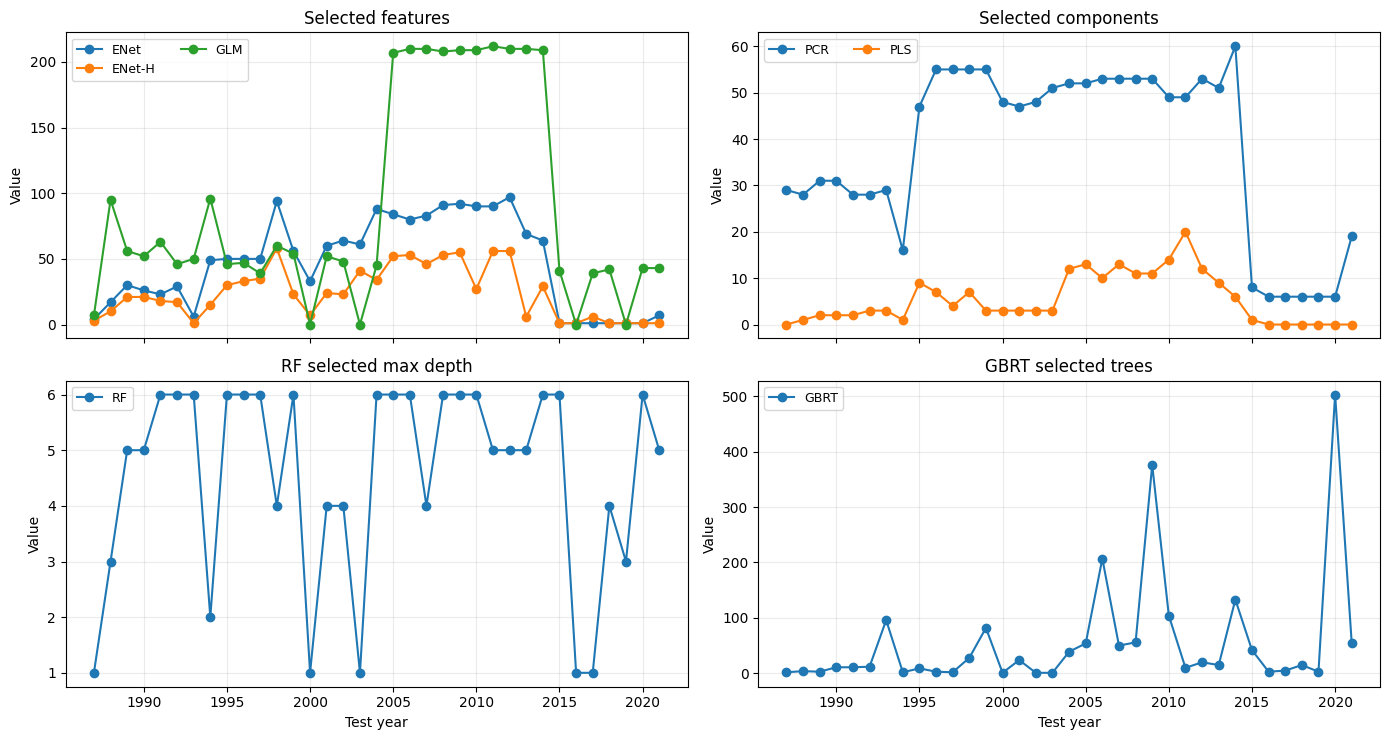

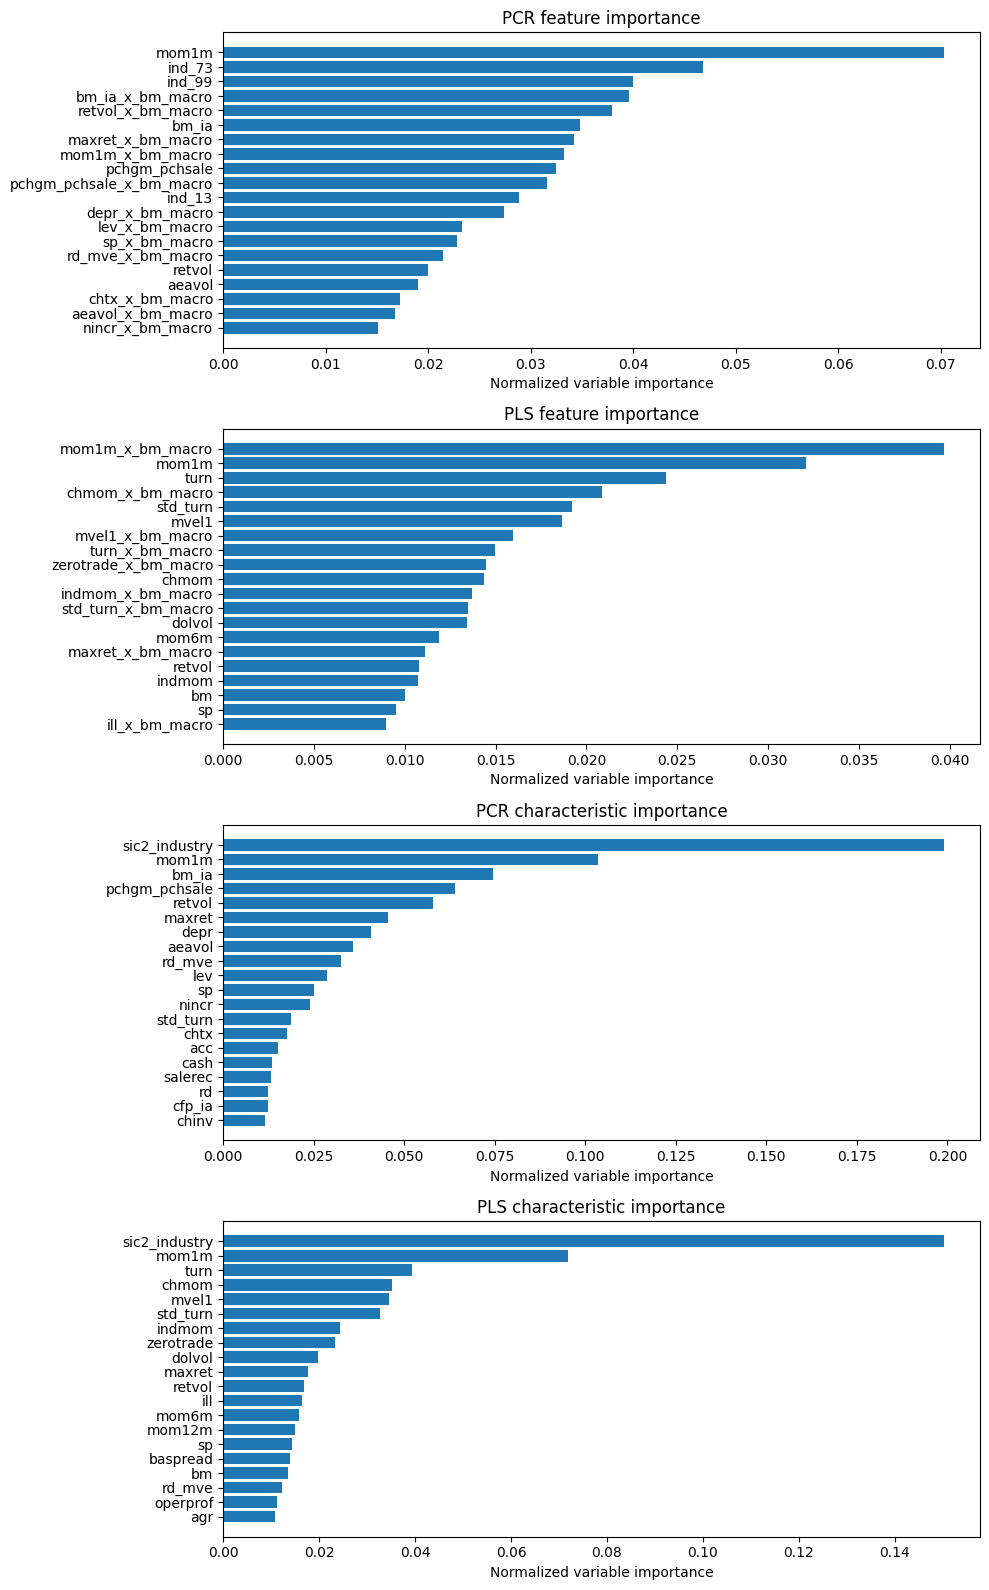

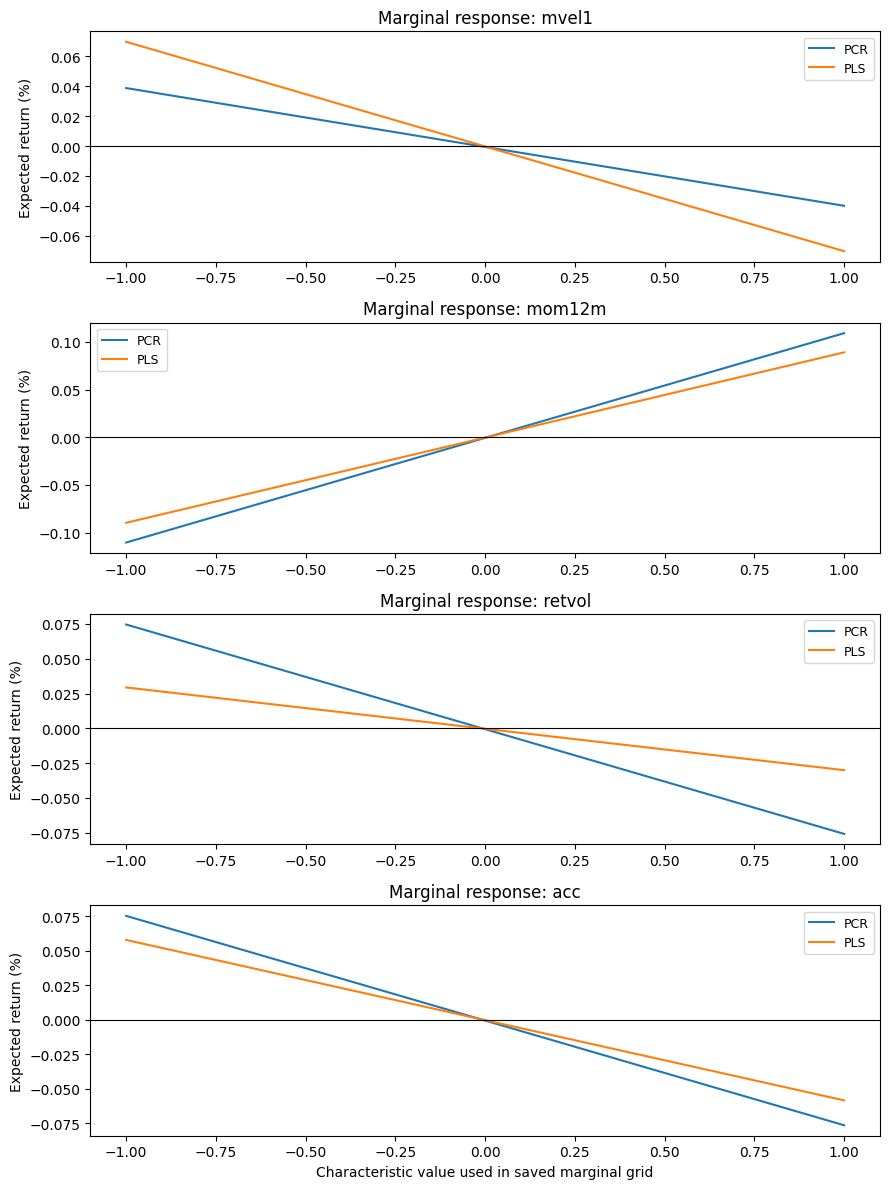

In [14]:
# ====================================================
# Paper Figure 3-style complexity and saved importance plots
# ====================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

PROJECT_ROOT = globals().get("PROJECT_ROOT", Path("/Users/julianreynolds/Project"))
RESULTS_DIR = globals().get("RESULTS_DIR", PROJECT_ROOT / "data" / "Results")
PCR_PLS_DIR = RESULTS_DIR / "pcr_pls"
FML_DIR = RESULTS_DIR / "fml_ols_enet_results"
GLM_DIR = RESULTS_DIR / "glm_3"
TREE_DIR = RESULTS_DIR / "tree_results"

complexity_frames = []


def add_parquet_complexity(path, model_label, value_col, metric_label):
    """Summarize repeated stock-level diagnostic columns into one value per test year."""
    path = Path(path)
    if not path.exists():
        return
    df = pd.read_parquet(path, columns=["test_year", value_col])
    yearly = (
        df.dropna(subset=["test_year", value_col])
        .groupby("test_year", observed=True)[value_col]
        .median()
        .reset_index(name="value")
    )
    yearly["model"] = model_label
    yearly["metric"] = metric_label
    complexity_frames.append(yearly)


# ENet and GLM files contain the number of selected/active features in the saved predictions.
add_parquet_complexity(
    FML_DIR / "FML_OLS_ENet_fixed_enet_recursive_oos_predictions.parquet",
    "ENet",
    "n_nonzero_features",
    "Selected features",
)
add_parquet_complexity(
    FML_DIR / "FML_OLS_ENet_fixed_enet_h_recursive_oos_predictions.parquet",
    "ENet-H",
    "n_nonzero_features",
    "Selected features",
)
add_parquet_complexity(
    GLM_DIR / "glm_3_stock_level_oos_predictions_with_ids.parquet",
    "GLM",
    "active_features",
    "Selected features",
)

# PCR/PLS yearly summaries contain the selected number of components.
for model_label, file_name in [("PCR", "pcr_yearly_summary.csv"), ("PLS", "pls_yearly_summary.csv")]:
    path = PCR_PLS_DIR / file_name
    if path.exists():
        yearly = pd.read_csv(path, usecols=["test_year", "best_k"])
        yearly = yearly.rename(columns={"best_k": "value"})
        yearly["model"] = model_label
        yearly["metric"] = "Selected components"
        complexity_frames.append(yearly)

# Tree-model complexity diagnostics. GBRT max depth is intentionally omitted; keep selected trees.
# RF selected max depth is read from structured diagnostics when present, otherwise from saved tree-model logs.
def add_rf_depth_complexity():
    depth_cols = ["max_depth", "selected_max_depth", "best_max_depth", "rf_max_depth"]
    rf_diag_paths = [
        TREE_DIR / "rf_test_diagnostics.csv",
        TREE_DIR / "rf_tuning_diagnostics.csv",
        TREE_DIR / "rf_diagnostics.csv",
    ]
    rf_diag_paths.extend(sorted(TREE_DIR.glob("*rf*diagnostic*.csv")))

    for path in dict.fromkeys(rf_diag_paths):
        if not path.exists():
            continue
        rf_diag = pd.read_csv(path)
        for depth_col in depth_cols:
            if {"test_year", depth_col}.issubset(rf_diag.columns):
                yearly = rf_diag[["test_year", depth_col]].rename(columns={depth_col: "value"}).copy()
                yearly = yearly.dropna(subset=["test_year", "value"]).drop_duplicates("test_year", keep="last")
                yearly["model"] = "RF"
                yearly["metric"] = "RF selected max depth"
                complexity_frames.append(yearly)
                return True

    tree_notebook_path = PROJECT_ROOT / "Notebooks for Methodology" / "tree_models_replication.ipynb"
    if not tree_notebook_path.exists():
        return False

    import ast
    import json
    import re

    pattern = re.compile(r"\[(\d{4})\]\s+Best RF Params:\s+(\{.*?\})")
    rows = []
    tree_nb = json.loads(tree_notebook_path.read_text())
    for cell in tree_nb.get("cells", []):
        for output in cell.get("outputs", []):
            text = output.get("text", "")
            if isinstance(text, list):
                text = "".join(text)
            for match in pattern.finditer(text):
                try:
                    params = ast.literal_eval(match.group(2))
                except (SyntaxError, ValueError):
                    continue
                depth = params.get("max_depth")
                if depth is not None:
                    rows.append({"test_year": int(match.group(1)), "value": depth})

    if not rows:
        return False
    yearly = pd.DataFrame(rows).drop_duplicates("test_year", keep="last").sort_values("test_year")
    yearly["model"] = "RF"
    yearly["metric"] = "RF selected max depth"
    complexity_frames.append(yearly)
    return True


if not add_rf_depth_complexity():
    print("RF selected max-depth diagnostics were not found in structured tree files or tree-model logs.")

gbrt_diag_path = TREE_DIR / "gbrt_test_diagnostics.csv"
if gbrt_diag_path.exists():
    gbrt_diag = pd.read_csv(gbrt_diag_path)
    value_col = "selected_n_estimators"
    if value_col in gbrt_diag.columns:
        yearly = gbrt_diag[["test_year", value_col]].rename(columns={value_col: "value"}).copy()
        yearly["model"] = "GBRT"
        yearly["metric"] = "GBRT selected trees"
        complexity_frames.append(yearly)

if complexity_frames:
    complexity_table = pd.concat(complexity_frames, ignore_index=True)
    print("Available Figure 3-style model complexity diagnostics:")
    display(complexity_table.head(20))

    metric_grid = [
        ["Selected features", "Selected components"],
        ["RF selected max depth", "GBRT selected trees"],
    ]
    available_metrics = set(complexity_table["metric"].dropna().unique())
    fig, axes = plt.subplots(2, 2, figsize=(14, 7.5), sharex=True)
    for row_idx, metric_row in enumerate(metric_grid):
        for col_idx, metric in enumerate(metric_row):
            ax = axes[row_idx, col_idx]
            if metric not in available_metrics:
                ax.axis("off")
                continue
            metric_data = complexity_table.loc[complexity_table["metric"].eq(metric)]
            for model_name, model_data in metric_data.groupby("model", observed=True):
                model_data = model_data.sort_values("test_year")
                ax.plot(model_data["test_year"], model_data["value"], marker="o", linewidth=1.5, label=model_name)
            ax.set_title(metric)
            ax.set_ylabel("Value")
            ax.grid(alpha=0.25)
            ax.legend(ncol=2, fontsize=9)
            if row_idx == len(metric_grid) - 1:
                ax.set_xlabel("Test year")
    fig.tight_layout()
    plt.show()
else:
    print("No saved complexity diagnostics found in the Results folder.")

# Saved PCR/PLS variable-importance files let us recreate a subset of the paper's importance analysis.
importance_specs = [
    ("PCR feature importance", PCR_PLS_DIR / "pcr_variable_importance.csv", "feature", "vi_normalized"),
    ("PLS feature importance", PCR_PLS_DIR / "pls_variable_importance.csv", "feature", "vi_normalized"),
    ("PCR characteristic importance", PCR_PLS_DIR / "pcr_char_importance.csv", "char", "vi_normalized_char"),
    ("PLS characteristic importance", PCR_PLS_DIR / "pls_char_importance.csv", "char", "vi_normalized_char"),
]
existing_importance = [spec for spec in importance_specs if spec[1].exists()]
if existing_importance:
    fig, axes = plt.subplots(len(existing_importance), 1, figsize=(10, 4 * len(existing_importance)))
    if len(existing_importance) == 1:
        axes = [axes]
    for ax, (title, path, label_col, value_col) in zip(axes, existing_importance):
        df = pd.read_csv(path)
        top = df.dropna(subset=[label_col, value_col]).nlargest(20, value_col).sort_values(value_col)
        ax.barh(top[label_col], top[value_col])
        ax.set_title(title)
        ax.set_xlabel("Normalized variable importance")
    fig.tight_layout()
    plt.show()
else:
    print("No PCR/PLS variable-importance files found.")

# PCR/PLS marginal-response files are also available. These are useful for paper-style
# marginal relationship plots, but only for the characteristics saved by those notebooks.
marginal_frames = []
for model_label, file_name in [("PCR", "marginals_pcr.csv"), ("PLS", "marginals_pls.csv")]:
    path = PCR_PLS_DIR / file_name
    if path.exists():
        marginal_frames.append(pd.read_csv(path).assign(model=model_label))

if marginal_frames:
    pcr_pls_marginals = pd.concat(marginal_frames, ignore_index=True)
    chars_to_plot = list(pcr_pls_marginals["char"].drop_duplicates()[:6])
    fig, axes = plt.subplots(len(chars_to_plot), 1, figsize=(9, 3.0 * len(chars_to_plot)), sharex=False)
    if len(chars_to_plot) == 1:
        axes = [axes]
    for ax, char_name in zip(axes, chars_to_plot):
        char_data = pcr_pls_marginals.loc[pcr_pls_marginals["char"].eq(char_name)]
        for model_name, model_data in char_data.groupby("model", observed=True):
            model_data = model_data.sort_values("x_value")
            ax.plot(model_data["x_value"], 100 * model_data["expected_return"], label=model_name)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"Marginal response: {char_name}")
        ax.set_ylabel("Expected return (%)")
        ax.legend(fontsize=9)
    axes[-1].set_xlabel("Characteristic value used in saved marginal grid")
    fig.tight_layout()
    plt.show()
else:
    print("No PCR/PLS marginal-response files found.")
